# Part 3 - A: BatchNorm, Dropout, Augmentation, Residual Block

## Prepare and define the necessary functions to run experiments

Imports and constants

In [1]:
import os
import json
import time
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.models import Model

TRAIN_DIR = "data/PlantVillage/train"
VAL_DIR = "data/PlantVillage/val"
RESULTS_CSV = "results.csv"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

/Users/myomyataung/workspace/projects/python/-practice-project--plant-disease-classifier/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Class names

In [2]:
# Only the class names are kept; the dataset object is discarded
class_names = tf.keras.utils.image_dataset_from_directory(
  TRAIN_DIR,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  label_mode="categorical",
  shuffle=False,
).class_names
print(len(class_names), class_names[:5])

Found 43444 files belonging to 38 classes.
38 ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


Data pipeline

In [3]:
normalize = tf.keras.layers.Rescaling(1.0/255)
AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, training=False, seed=SEED):
  ds = ds.unbatch()                                                                # unbatch the dataset
  ds = ds.map(lambda x, y: (tf.cast(x, tf.uint8), y), num_parallel_calls=AUTOTUNE) # unit8
  ds = ds.cache()                  
  if training:
    ds = ds.shuffle(1000, seed=seed)                                                 # remix every epoch
  ds = ds.batch(BATCH_SIZE)
  ds = ds.map(lambda x, y: (normalize(x), y), num_parallel_calls=AUTOTUNE)
  return ds.prefetch(AUTOTUNE)                                                     # Prepare next batch while training on GPU

def make_datasets(seed=SEED):
  train = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=seed,
  )
  val = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
    seed=seed,
  )
  return prepare(train, training=True, seed=seed), prepare(val, seed=seed)

Watch pairs

In [4]:
# Classes to compare across runs (exact names from class_names).
WATCH_PAIRS = [
  ("corn_cerc_to_nlb", "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot", "Corn_(maize)___Northern_Leaf_Blight"),
  ("corn_nlb_to_cerc", "Corn_(maize)___Northern_Leaf_Blight", "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot"),
  ("peach_to_apple", "Peach___healthy", "Apple___healthy"),
  ("tom_early_to_late", "Tomato___Early_blight", "Tomato___Late_blight")
  ]

# Fail fast: a typo here would otherwise only crash at the end of evaluate_experiment, after training
missing = [name for _, t, p in WATCH_PAIRS for name in (t, p) if name not in class_names]
assert not missing, f"WATCH_PAIRS names not in class_names: {missing}"
print(f"WATCH_PAIRS OK ({len(WATCH_PAIRS)} pairs)")

WATCH_PAIRS OK (4 pairs)


Evaluation and experiment helpers

In [5]:
def evaluate_per_class(model, ds, title, top_k=10):
  # Labels and predictions (val_ds is unshuffled, so the order matches)
  y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in ds])
  y_pred = np.argmax(model.predict(ds, verbose=0), axis=1)

  # 1. Classification report
  print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

  # 2. Confusion matrix: colour = row-normalised (recall), text = raw counts
  cm = confusion_matrix(y_true, y_pred)
  support = cm.sum(axis=1)
  cm_norm = cm / support[:, None]
  annot = np.where(cm > 0, cm.astype(str), "")
  labels = [c.replace("___", " - ").replace("_", " ") for c in class_names]

  fig, ax = plt.subplots(figsize=(18, 16))
  sns.heatmap(
    cm_norm,
    annot=annot,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 7},
    linewidths=0.3,
    linecolor="lightgray",
    square=True,
    cbar_kws={"label": "Fraction of true class (recall)", "shrink": 0.8},
    ax=ax,
  )
  ax.set_xlabel("Predicted")
  ax.set_ylabel("True")
  ax.set_title(title)
  plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
  plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
  plt.tight_layout()
  plt.show()

  # 3. Top-k most frequent misclassifications (off-diagonal cells)
  off_diag = cm.copy()
  np.fill_diagonal(off_diag, 0)
  top = np.argsort(off_diag, axis=None)[::-1][:top_k]
  rows, cols = np.unravel_index(top, off_diag.shape)

  print(f"\nTop {top_k} confusions")
  print(f"{'count':>5}  {'% of true':>9}  {'total':>5}  true -> predicted")
  for t, p in zip(rows, cols):
    if off_diag[t, p] == 0:
      break
    print(f"{off_diag[t, p]:5d}  {off_diag[t, p] / support[t]:9.1%}  {support[t]:5d}  "
          f"{class_names[t]} -> {class_names[p]}")

  return cm

In [6]:
def log_history(filename, n_epochs=None):
  with open(filename) as f:
    hist = json.load(f)

  metrics = [k for k in hist if not k.startswith("val_")]
  total = len(hist["loss"])
  n_epochs = total if n_epochs is None else min(n_epochs, total)

  print(f"{filename}  ({total} epochs)")
  print(f"{'epoch':>5}  {'split':<5}" + "".join(f"{m:>11}" for m in metrics))
  for e in range(n_epochs):
    print(f"{e + 1:5d}  {'train':<5}" + "".join(f"{hist[m][e]:11.4f}" for m in metrics))
    if "val_loss" in hist:
      # metrics like epoch_time have no val_ version, so leave that cell blank
      print(f"{'':5}  {'val':<5}" + "".join(
        f"{hist['val_' + m][e]:11.4f}" if f"val_{m}" in hist else f"{'':>11}"
        for m in metrics))

  return hist

In [25]:
class EpochTimer(tf.keras.callbacks.Callback):
  # Adds "epoch_time" (seconds, train + validation) to the epoch logs,
  # so it ends up in history, the CSV log and the progress bar
  def on_epoch_begin(self, epoch, logs=None):
    self.start = time.time()

  def on_epoch_end(self, epoch, logs=None):
    logs["epoch_time"] = time.time() - self.start

def run_experiment(run_name, build_fn, epochs=30, patience=5, overwrite=False, seed=SEED, extra_callbacks=None):
  # 0. Protect existing results from being overwritten
  paths = {
    "model":   f"{run_name}.keras",
    "history": f"history_{run_name}.json",
    "csv":     f"history_{run_name}.csv",
  }
  existing = [p for p in paths.values() if os.path.exists(p)]
  if existing and not overwrite:
    if len(existing) == len(paths):
      # All 3 files exist = training finished (the JSON is written last, only after fit() returns)
      print(f"[{run_name}] already trained, skipping. Pass overwrite=True to retrain.")
      return None, None
    missing = [p for p in paths.values() if p not in existing]
    raise FileExistsError(
      f"[{run_name}] incomplete run (crashed?): found {', '.join(existing)}, "
      f"missing {', '.join(missing)}. Inspect them, then pass overwrite=True to retrain."
    )
  if existing:
    print(f"[{run_name}] overwrite=True, removing: {', '.join(existing)}")
    for p in existing:
      os.remove(p)   # so a crashed run can't leave old and new files mixed together

  # 1. Seed Python, NumPy and TensorFlow so runs can be reproduced and compared
  tf.keras.backend.clear_session()  # clear any old models from memory
  tf.keras.utils.set_random_seed(seed)

  # 2. Fresh datasets (new shuffle state for each run)
  train_ds, val_ds = make_datasets(seed=seed)

  # 3. Build and compile the model (new weight init)
  model = build_fn(len(class_names))
  model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy',
          tf.keras.metrics.Precision(name='precision'),
          tf.keras.metrics.Recall(name='recall')
          ]
    )
  
  # 4. Callbacks
  callbacks = [
    EpochTimer(),   # must be first, so the callbacks after it see "epoch_time"
    *(extra_callbacks or []),
    tf.keras.callbacks.EarlyStopping(
      monitor="val_loss",
      patience=patience,
      restore_best_weights=True,
      verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
      paths["model"],
      monitor="val_loss",
      save_best_only=True,
    ),
    tf.keras.callbacks.CSVLogger(paths["csv"]),   # writes a row each epoch, so it survives a crash
  ]

  # 5. Fit
  history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,           # EarlyStopping will stop earlier if no improvement
    callbacks=callbacks,
  )

  # 6. Save the history as JSON
  with open(paths["history"], "w") as f:
    json.dump({k: [float(v) for v in vals]
                 for k, vals in history.history.items()}, f)

  best_epoch = int(np.argmin(history.history["val_loss"])) + 1
  print(f"[{run_name}] epochs run: {len(history.history['loss'])}, best epoch: {best_epoch}")

  return model, history

In [8]:
def evaluate_experiment(run_name, top_k=10, n_worst=5, n_epochs=None):
  # 1. Load the best checkpoint saved by run_experiment
  model = tf.keras.models.load_model(f"{run_name}.keras")
  _, val_ds = make_datasets()

  # 2. Evaluate, and check against the best epoch in the history
  results = model.evaluate(val_ds, return_dict=True, verbose=0)
  with open(f"history_{run_name}.json") as f:
    hist = json.load(f)
  best = int(np.argmin(hist["val_loss"]))
  print(f"[{run_name}] best epoch: {best + 1} / {len(hist['loss'])}")
  print(f"{'metric':<10}{'evaluate':>10}{'history':>10}")
  for m, v in results.items():
    print(f"{m:<10}{v:10.4f}{hist['val_' + m][best]:10.4f}")
  print()

  # 3-5. Classification report, confusion matrix, top-k confusions
  cm = evaluate_per_class(model, val_ds, run_name, top_k=top_k)

  # 6. Lowest Recall
  support = cm.sum(axis=1)
  predicted = cm.sum(axis=0)
  tp = np.diag(cm)
  recall = tp / np.maximum(support, 1)
  precision = tp / np.maximum(predicted, 1)
  f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

  idx = list(np.argsort(recall)[:n_worst])
  print(f"\nWatch list (lowest {n_worst} recall)")

  off_diag = cm.copy()
  np.fill_diagonal(off_diag, 0)
  print(f"{'precision':>9}  {'recall':>6}  {'f1':>6}  {'total':>5}  class -> most confused with")
  for i in idx:
    j = int(np.argmax(off_diag[i]))
    confused = f"{class_names[j]} ({off_diag[i, j]})" if off_diag[i, j] > 0 else "-"
    print(f"{precision[i]:9.3f}  {recall[i]:6.3f}  {f1[i]:6.3f}  {support[i]:5d}  "
          f"{class_names[i]} -> {confused}")
  print()

  # 7. History log
  log_history(f"history_{run_name}.json", n_epochs)

  # 8. Summary row in results.csv (replaces the row if this run_name is already there)
  epoch_times = hist.get("epoch_time", [])   # missing for runs trained before EpochTimer
  row = {
    "run_name": run_name,
    "evaluated_at": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "params": model.count_params(),
    "epochs_run": len(hist["loss"]),
    "best_epoch": best + 1,
    "best_val_loss": hist["val_loss"][best],
    "val_accuracy": results["accuracy"],
    "macro_f1": float(f1.mean()),
    "epoch1_sec": epoch_times[0] if epoch_times else np.nan,                           # includes cache filling
    "epoch_sec": float(np.mean(epoch_times[1:])) if len(epoch_times) > 1 else np.nan,  # mean of epochs 2+
  }
  
  support = cm.sum(axis=1)          # images per TRUE class (row sums)

  watch = {}
  print("\nWatch pairs")
  for label, true_name, pred_name in WATCH_PAIRS:
      t = class_names.index(true_name)   # row
      p = class_names.index(pred_name)   # column
      count = int(cm[t, p])
      pct = 100 * count / support[t]

      watch[f"watch_{label}_pct"] = round(float(pct), 1)
      print(f"{label:<20} {count:>4} / {support[t]:<4} = {pct:5.1f}%")
      
  row.update(watch)
  
  df = pd.DataFrame([row])
  if os.path.exists(RESULTS_CSV):
    old = pd.read_csv(RESULTS_CSV)
    old = old[old["run_name"] != run_name]
    if len(old):
      df = pd.concat([old, df], ignore_index=True)
  df.to_csv(RESULTS_CSV, index=False)
  print(f"\nSaved [{run_name}] to {RESULTS_CSV}")

  return model, results, cm

Build functions

In [9]:
def build_model(n_classes):
  inputs = Input(shape=(128, 128, 3))
  x = Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same')(inputs)
  x = MaxPooling2D(pool_size=(3, 3))(x)
  x = Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same')(x)
  x = MaxPooling2D(pool_size=(3, 3))(x)
  x = Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same')(x)
  x = MaxPooling2D(pool_size=(3, 3))(x)
  x = Flatten()(x)
  x = Dense(128, activation='relu')(x)
  outputs = Dense(n_classes, activation='softmax')(x)

  model = Model(inputs=inputs, outputs=outputs)
  return model

In [26]:
def build_bn_model(n_classes, bn_momentum=0.99):
  # bn_momentum: how slowly the BN moving mean/variance follow each batch.
  # 0.99 (Keras default) ≈ average over the last ~100 batches, 0.9 ≈ last ~10
  inputs = Input(shape=(128, 128, 3))

  x = Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False)(inputs)
  x = BatchNormalization(momentum=bn_momentum)(x)
  x = Activation('relu')(x)
  x = MaxPooling2D(pool_size=(3, 3))(x)

  x = Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False)(x)
  x = BatchNormalization(momentum=bn_momentum)(x)
  x = Activation('relu')(x)
  x = MaxPooling2D(pool_size=(3, 3))(x)

  x = Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False)(x)
  x = BatchNormalization(momentum=bn_momentum)(x)
  x = Activation('relu')(x)
  x = MaxPooling2D(pool_size=(3, 3))(x)

  x = Flatten()(x)
  x = Dense(128, activation='relu')(x)
  outputs = Dense(n_classes, activation='softmax')(x)

  model = Model(inputs=inputs, outputs=outputs)
  return model

## Run Deterministic Experiments

Determinism check with 1 epoch

In [11]:
run_experiment("det_a", build_model, epochs=1)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
   1357/Unknown 117s 85ms/step - accuracy: 0.4915 - loss: 1.8631 - precision: 0.7896 - recall: 0.3478

2026-10-06 21:27:51.721229: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/Users/myomyataung/workspace/projects/python/-practice-project--plant-disease-classifier/.venv/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 124s 91ms/step - accuracy: 0.4918 - loss: 1.8620 - precision: 0.7897 - recall: 0.3481 - val_accuracy: 0.8242 - val_loss: 0.5473 - val_precision: 0.8927 - val_recall: 0.7704 - epoch_time: 124.1200
Restoring model weights from the end of the best epoch: 1.
[det_a] epochs run: 1, best epoch: 1


2026-10-06 21:27:58.944066: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


(<Functional name=functional, built=True>,
 <keras.src.callbacks.history.History at 0x30e468f40>)

In [12]:
run_experiment("det_b", build_model, epochs=1)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 94s 68ms/step - accuracy: 0.4918 - loss: 1.8620 - precision: 0.7897 - recall: 0.3481 - val_accuracy: 0.8242 - val_loss: 0.5473 - val_precision: 0.8927 - val_recall: 0.7704 - epoch_time: 93.7594
Restoring model weights from the end of the best epoch: 1.
[det_b] epochs run: 1, best epoch: 1


2026-10-06 21:29:34.839128: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


(<Functional name=functional, built=True>,
 <keras.src.callbacks.history.History at 0x31271c5e0>)

## Run B0 (Baseline 0) Experiments

B0 models is already trianed and saved as `B0.keras`. Only need to evaluate. Run `evaluate_experiment("B0", 3)` to evaluate the model for 3 epochs.

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
[B0] best epoch: 11 / 16
metric      evaluate   history
accuracy      0.9498    0.9498
loss          0.1751    0.1751
precision     0.9542    0.9542
recall        0.9471    0.9471

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.851     0.905     0.877       126
                                 Apple___Black_rot      0.967     0.936     0.951       125
                          Apple___Cedar_apple_rust      0.867     0.945     0.904        55
                                   Apple___healthy      0.970     0.900     0.934       329
                               Blueberry___healthy      0.951     0.980     0.966       300
          Cherry_(including_sour)___Powdery_mildew      0.995     0.967     0.981       210
                 Cherry_(including_sour)___healthy      0.960     0.988     0.974       

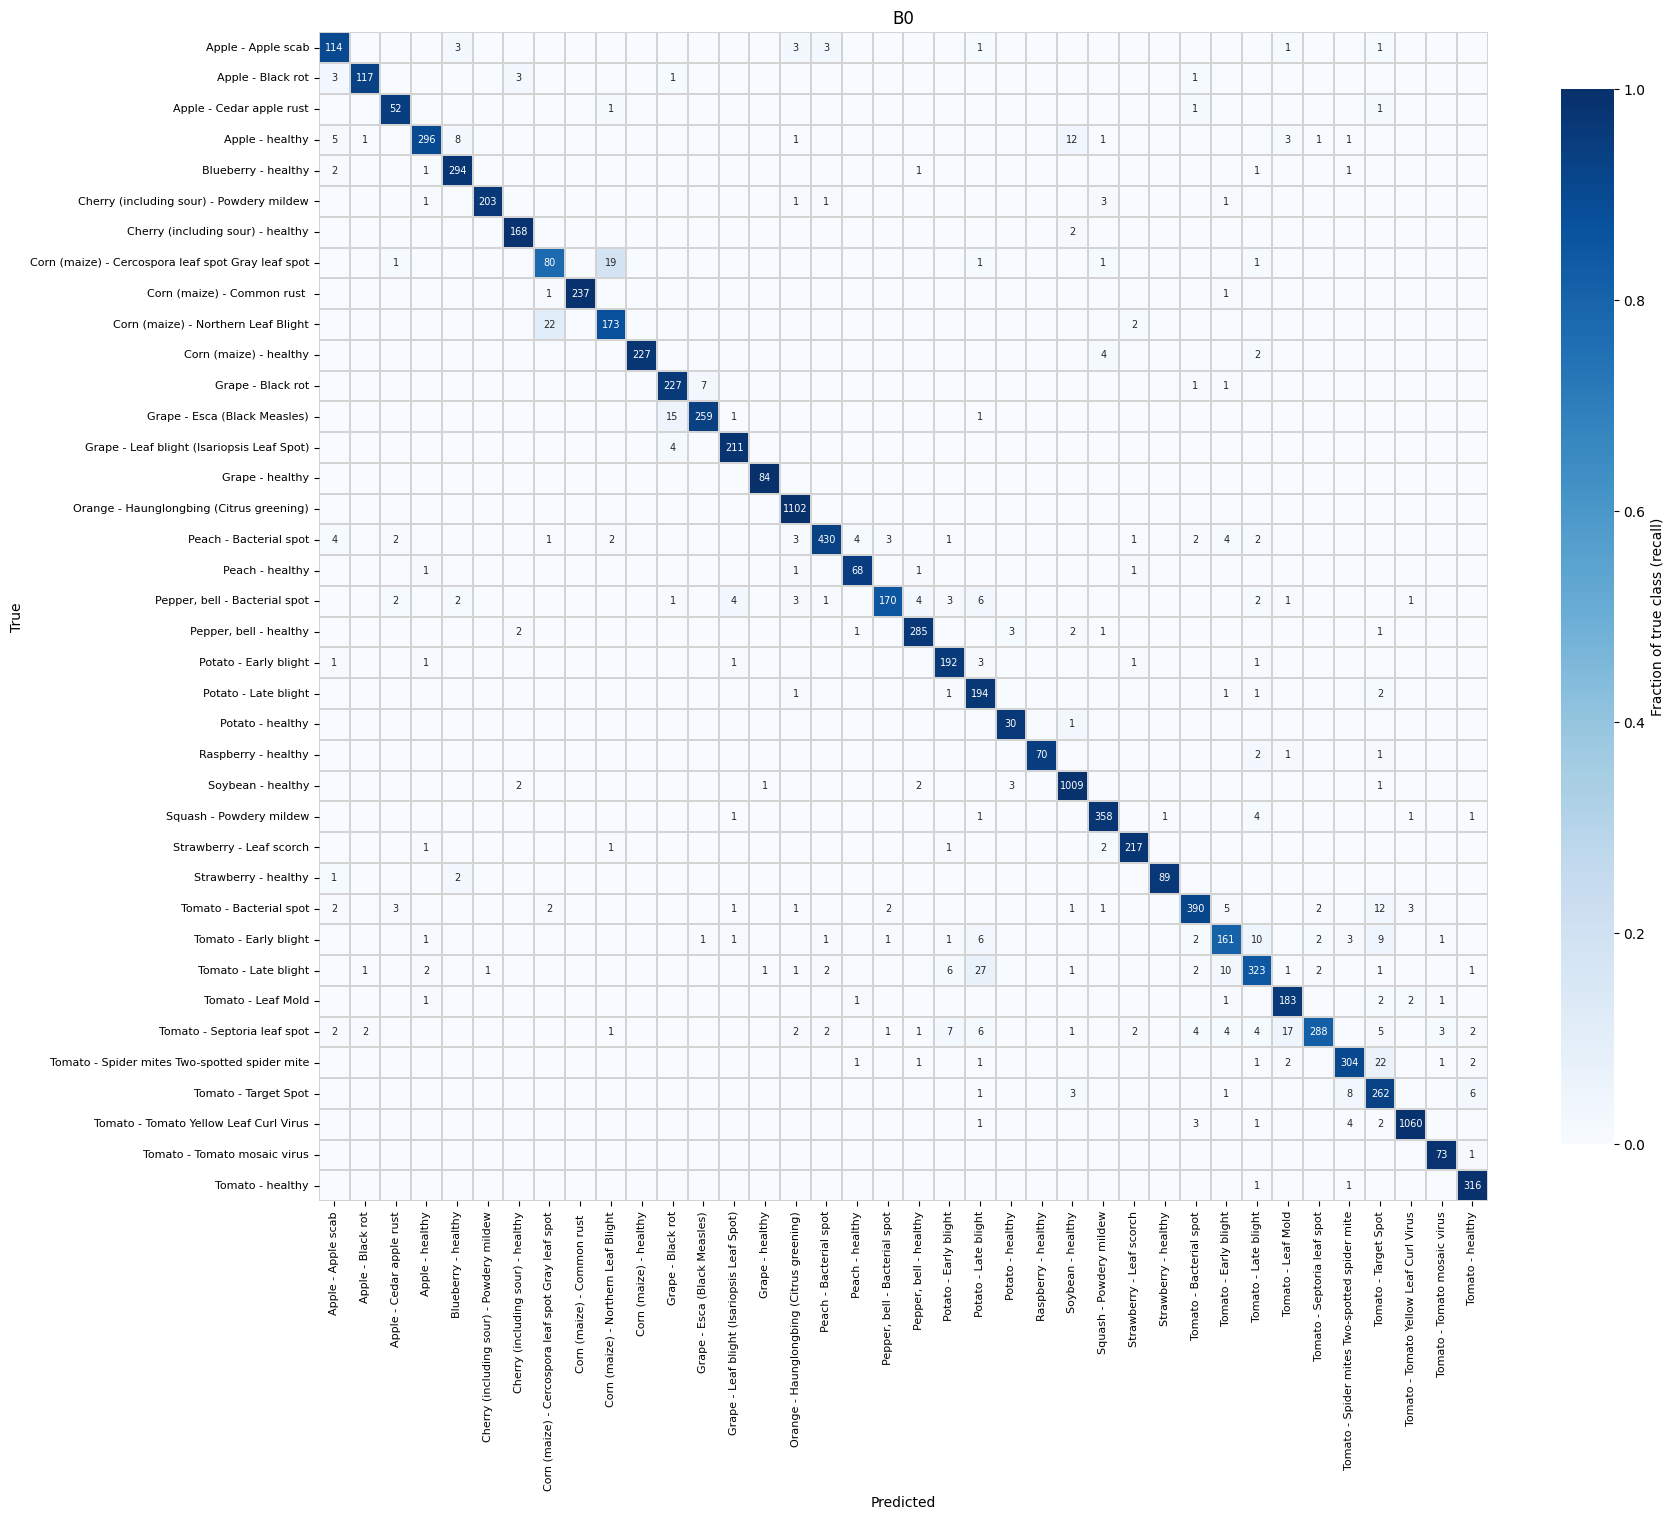


Top 10 confusions
count  % of true  total  true -> predicted
   27       7.1%    382  Tomato___Late_blight -> Potato___Late_blight
   22      11.2%    197  Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   22       6.6%    335  Tomato___Spider_mites Two-spotted_spider_mite -> Tomato___Target_Spot
   19      18.4%    103  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Corn_(maize)___Northern_Leaf_Blight
   17       4.8%    354  Tomato___Septoria_leaf_spot -> Tomato___Leaf_Mold
   15       5.4%    276  Grape___Esca_(Black_Measles) -> Grape___Black_rot
   12       3.6%    329  Apple___healthy -> Soybean___healthy
   12       2.8%    425  Tomato___Bacterial_spot -> Tomato___Target_Spot
   10       5.0%    200  Tomato___Early_blight -> Tomato___Late_blight
   10       2.6%    382  Tomato___Late_blight -> Tomato___Early_blight

Watch list (lowest 5 recall)
precision  recall      f1  total  class -> most confused with
    0.755   0.777   0.76

(<Functional name=functional, built=True>,
 {'accuracy': 0.9498204588890076,
  'loss': 0.17506687343120575,
  'precision': 0.9541743993759155,
  'recall': 0.9470582604408264},
 array([[ 114,    0,    0, ...,    0,    0,    0],
        [   3,  117,    0, ...,    0,    0,    0],
        [   0,    0,   52, ...,    0,    0,    0],
        ...,
        [   0,    0,    0, ..., 1060,    0,    0],
        [   0,    0,    0, ...,    0,   73,    1],
        [   0,    0,    0, ...,    0,    0,  316]]))

In [13]:
evaluate_experiment("B0", n_epochs=3)

## Run B1 (Baseline 1) Experiments - BatchNorm

Train the B1 model with BatchNorm and evaluate. Run `run_experiment("B1", build_bn_model)` to train the model. And run `evaluate_experiment("B1", 3)` to evaluate the model for 3 epochs.

In [14]:
run_experiment("B1", build_bn_model)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
Epoch 1/30
   1358/Unknown 220s 161ms/step - accuracy: 0.6576 - loss: 1.2588 - precision: 0.8568 - recall: 0.5382

2026-10-06 21:33:36.630450: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/Users/myomyataung/workspace/projects/python/-practice-project--plant-disease-classifier/.venv/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 232s 170ms/step - accuracy: 0.6576 - loss: 1.2584 - precision: 0.8568 - recall: 0.5383 - val_accuracy: 0.7659 - val_loss: 0.7776 - val_precision: 0.8185 - val_recall: 0.7331 - epoch_time: 232.0237
Epoch 2/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 222s 164ms/step - accuracy: 0.8992 - loss: 0.3172 - precision: 0.9236 - recall: 0.8790 - val_accuracy: 0.8173 - val_loss: 0.6779 - val_precision: 0.8418 - val_recall: 0.7985 - epoch_time: 222.1909
Epoch 3/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 223s 164ms/step - accuracy: 0.9319 - loss: 0.2120 - precision: 0.9447 - recall: 0.9221 - val_accuracy: 0.9039 - val_loss: 0.3106 - val_precision: 0.9184 - val_recall: 0.8927 - epoch_time: 223.2076
Epoch 4/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 236s 174ms/step - accuracy: 0.9499 - loss: 0.1490 - precision: 0.9562 - recall: 0.9435 - val_accuracy: 0.9316 - val_loss: 0.2137 - val_precision: 0.9394 - val_recall: 0.9255 - epoch_time: 236.0690
Epoch 5/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step

2026-10-06 21:49:06.098292: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 249s 183ms/step - accuracy: 0.9599 - loss: 0.1188 - precision: 0.9645 - recall: 0.9552 - val_accuracy: 0.8157 - val_loss: 0.6567 - val_precision: 0.8332 - val_recall: 0.8059 - epoch_time: 248.5131
Epoch 6/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 252s 186ms/step - accuracy: 0.9705 - loss: 0.0878 - precision: 0.9734 - recall: 0.9672 - val_accuracy: 0.9500 - val_loss: 0.1583 - val_precision: 0.9565 - val_recall: 0.9443 - epoch_time: 252.0832
Epoch 7/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 251s 185ms/step - accuracy: 0.9729 - loss: 0.0765 - precision: 0.9758 - recall: 0.9704 - val_accuracy: 0.9535 - val_loss: 0.1540 - val_precision: 0.9575 - val_recall: 0.9508 - epoch_time: 250.5834
Epoch 8/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 274s 202ms/step - accuracy: 0.9796 - loss: 0.0604 - precision: 0.9816 - recall: 0.9779 - val_accuracy: 0.9507 - val_loss: 0.1627 - val_precision: 0.9551 - val_recall: 0.9483 - epoch_time: 274.3687
Epoch 9/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 264s 195ms/st

2026-10-06 22:22:58.652092: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 243s 179ms/step - accuracy: 0.9856 - loss: 0.0406 - precision: 0.9863 - recall: 0.9848 - val_accuracy: 0.9553 - val_loss: 0.1690 - val_precision: 0.9576 - val_recall: 0.9541 - epoch_time: 243.3821
Epoch 14/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 246s 181ms/step - accuracy: 0.9892 - loss: 0.0332 - precision: 0.9897 - recall: 0.9886 - val_accuracy: 0.9346 - val_loss: 0.2626 - val_precision: 0.9385 - val_recall: 0.9321 - epoch_time: 245.7527
Epoch 15/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 230s 169ms/step - accuracy: 0.9916 - loss: 0.0277 - precision: 0.9920 - recall: 0.9911 - val_accuracy: 0.8990 - val_loss: 0.3978 - val_precision: 0.9054 - val_recall: 0.8949 - epoch_time: 230.1109
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 10.
[B1] epochs run: 15, best epoch: 10


(<Functional name=functional, built=True>,
 <keras.src.callbacks.history.History at 0x108025d30>)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
[B1] best epoch: 10 / 15
metric      evaluate   history
accuracy      0.9637    0.9637
loss          0.1298    0.1298
precision     0.9665    0.9665
recall        0.9617    0.9617

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      1.000     0.802     0.890       126
                                 Apple___Black_rot      0.976     0.984     0.980       125
                          Apple___Cedar_apple_rust      0.887     1.000     0.940        55
                                   Apple___healthy      0.987     0.918     0.951       329
                               Blueberry___healthy      0.977     0.980     0.978       300
          Cherry_(including_sour)___Powdery_mildew      1.000     0.990     0.995       210
                 Cherry_(including_sour)___healthy      0.948     0.965     0.956       

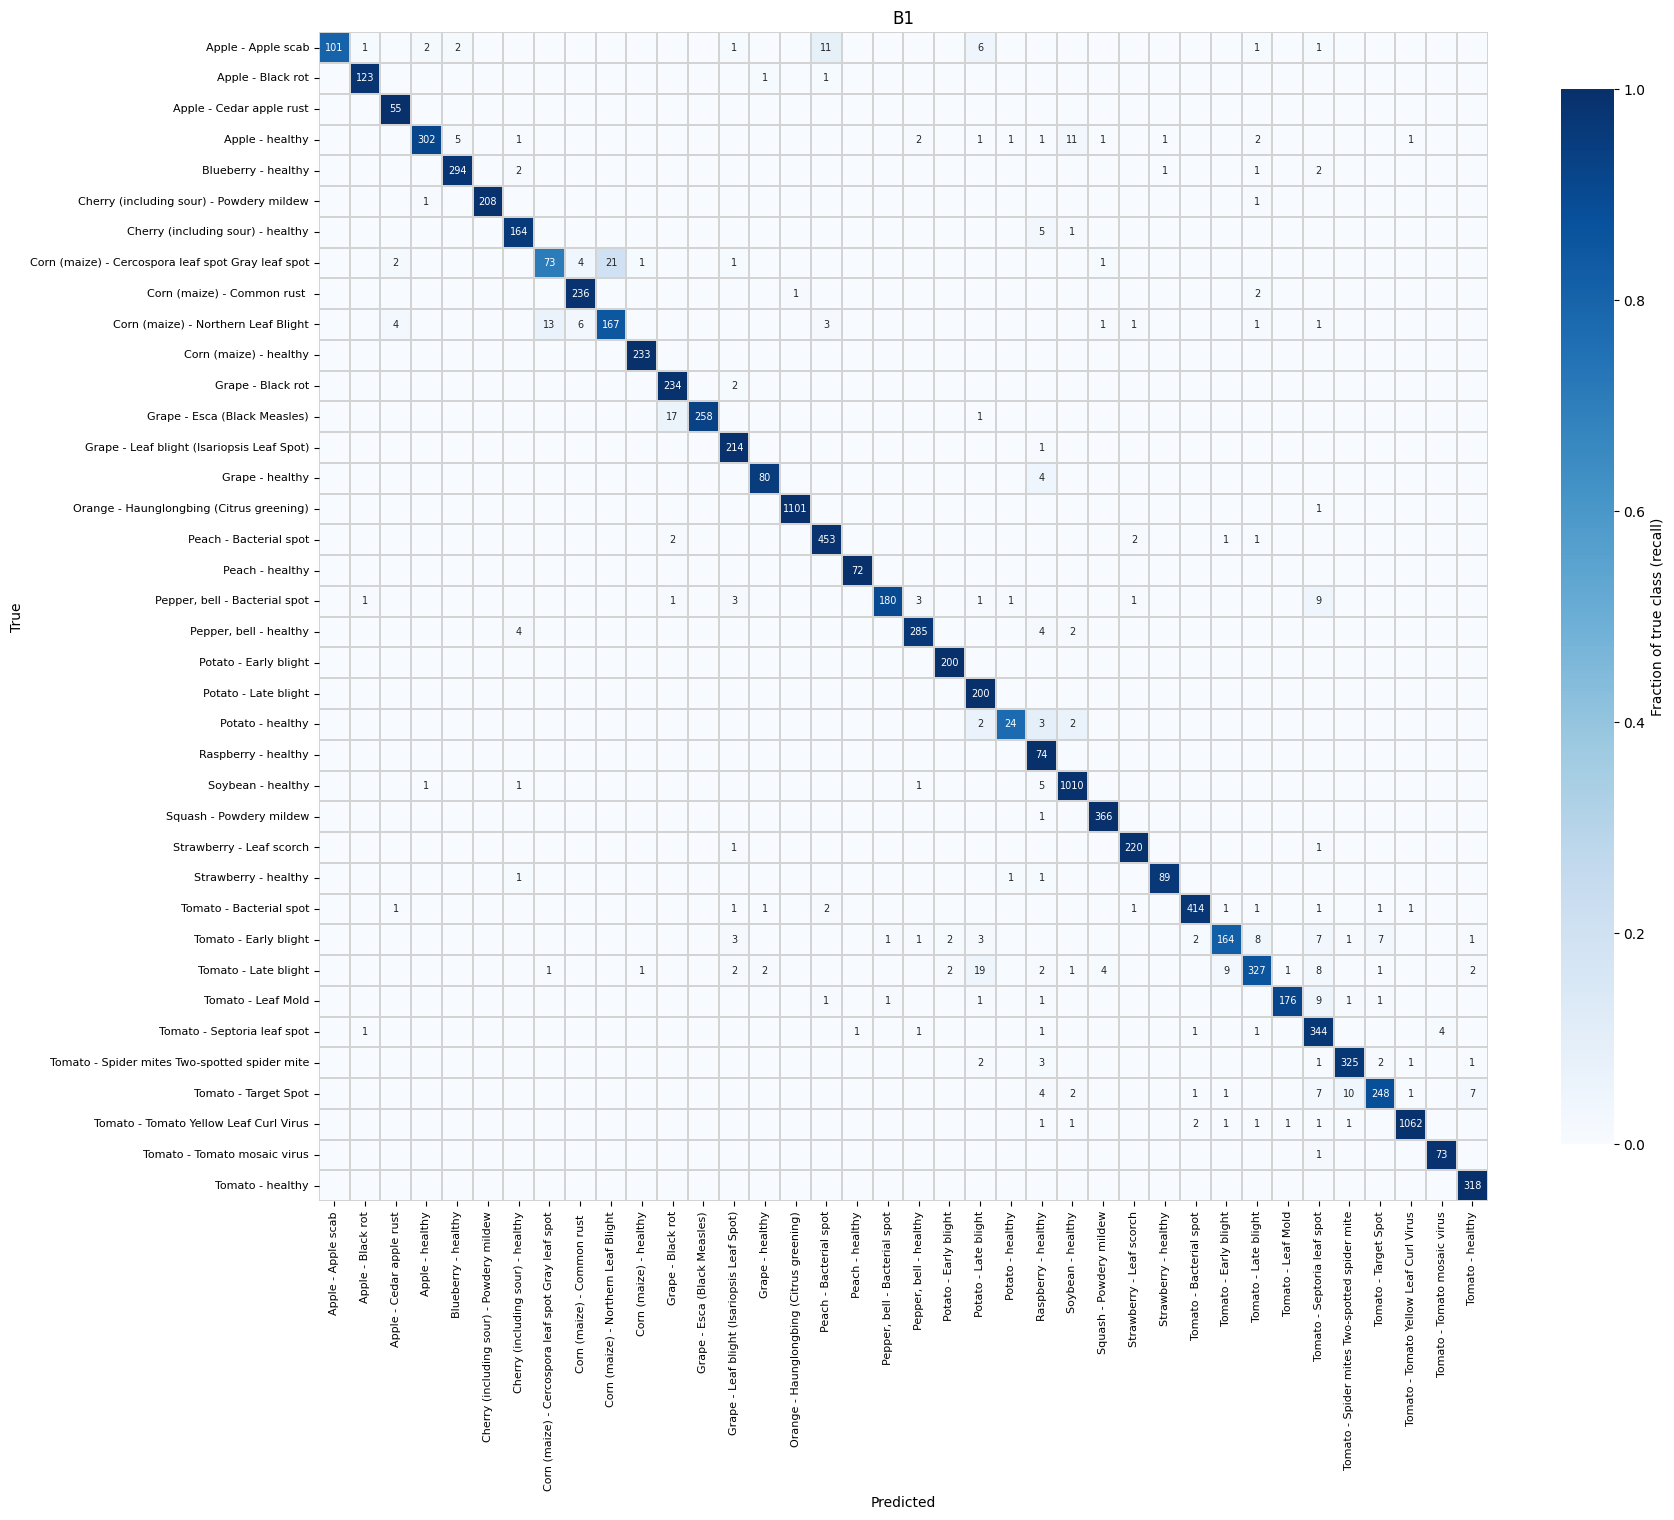


Top 10 confusions
count  % of true  total  true -> predicted
   21      20.4%    103  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Corn_(maize)___Northern_Leaf_Blight
   19       5.0%    382  Tomato___Late_blight -> Potato___Late_blight
   17       6.2%    276  Grape___Esca_(Black_Measles) -> Grape___Black_rot
   13       6.6%    197  Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   11       8.7%    126  Apple___Apple_scab -> Peach___Bacterial_spot
   11       3.3%    329  Apple___healthy -> Soybean___healthy
   10       3.6%    281  Tomato___Target_Spot -> Tomato___Spider_mites Two-spotted_spider_mite
    9       2.4%    382  Tomato___Late_blight -> Tomato___Early_blight
    9       4.5%    200  Pepper,_bell___Bacterial_spot -> Tomato___Septoria_leaf_spot
    9       4.7%    191  Tomato___Leaf_Mold -> Tomato___Septoria_leaf_spot

Watch list (lowest 5 recall)
precision  recall      f1  total  class -> most confused with
    0.839   

(<Functional name=functional, built=True>,
 {'accuracy': 0.9637234210968018,
  'loss': 0.12978921830654144,
  'precision': 0.9665032029151917,
  'recall': 0.9616978168487549},
 array([[ 101,    1,    0, ...,    0,    0,    0],
        [   0,  123,    0, ...,    0,    0,    0],
        [   0,    0,   55, ...,    0,    0,    0],
        ...,
        [   0,    0,    0, ..., 1062,    0,    0],
        [   0,    0,    0, ...,    0,   73,    0],
        [   0,    0,    0, ...,    0,    0,  318]]))

In [15]:
evaluate_experiment("B1")

Confirm BatchNormalization is working by checking the model with another seed. Run `run_experiment("B1_s43", build_bn_model, seed=43)` to traint the model with seed 43.
- `M` < 0.15: BN is working၊ build `B2` model with `B1` as baseline
- `M` is 0.15–0.18: unclear
- `M` > 0.18: seed 42 just lucky

In [16]:
run_experiment("B1_s43", build_bn_model, seed=43)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
Epoch 1/30
   1358/Unknown 247s 181ms/step - accuracy: 0.6582 - loss: 1.2664 - precision: 0.8437 - recall: 0.5440

/Users/myomyataung/workspace/projects/python/-practice-project--plant-disease-classifier/.venv/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 261s 191ms/step - accuracy: 0.6583 - loss: 1.2661 - precision: 0.8437 - recall: 0.5441 - val_accuracy: 0.7298 - val_loss: 0.9584 - val_precision: 0.7692 - val_recall: 0.6947 - epoch_time: 260.8557
Epoch 2/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 264s 194ms/step - accuracy: 0.9032 - loss: 0.3010 - precision: 0.9258 - recall: 0.8860 - val_accuracy: 0.8166 - val_loss: 0.5949 - val_precision: 0.8454 - val_recall: 0.7910 - epoch_time: 264.0728
Epoch 3/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 229s 169ms/step - accuracy: 0.9365 - loss: 0.1971 - precision: 0.9477 - recall: 0.9265 - val_accuracy: 0.7588 - val_loss: 0.9151 - val_precision: 0.7868 - val_recall: 0.7401 - epoch_time: 229.1301
Epoch 4/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 227s 167ms/step - accuracy: 0.9483 - loss: 0.1529 - precision: 0.9556 - recall: 0.9415 - val_accuracy: 0.8911 - val_loss: 0.3539 - val_precision: 0.9031 - val_recall: 0.8834 - epoch_time: 226.9613
Epoch 5/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 224s 165ms/st

2026-10-06 23:22:03.965129: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


(<Functional name=functional, built=True>,
 <keras.src.callbacks.history.History at 0x10c43f700>)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
[B1_s43] best epoch: 7 / 12
metric      evaluate   history
accuracy      0.9506    0.9506
loss          0.1546    0.1546
precision     0.9548    0.9548
recall        0.9466    0.9466

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.833     0.913     0.871       126
                                 Apple___Black_rot      0.947     0.992     0.969       125
                          Apple___Cedar_apple_rust      0.942     0.891     0.916        55
                                   Apple___healthy      0.977     0.909     0.942       329
                               Blueberry___healthy      0.971     0.997     0.984       300
          Cherry_(including_sour)___Powdery_mildew      1.000     0.967     0.983       210
                 Cherry_(including_sour)___healthy      0.966     0.988     0.977    

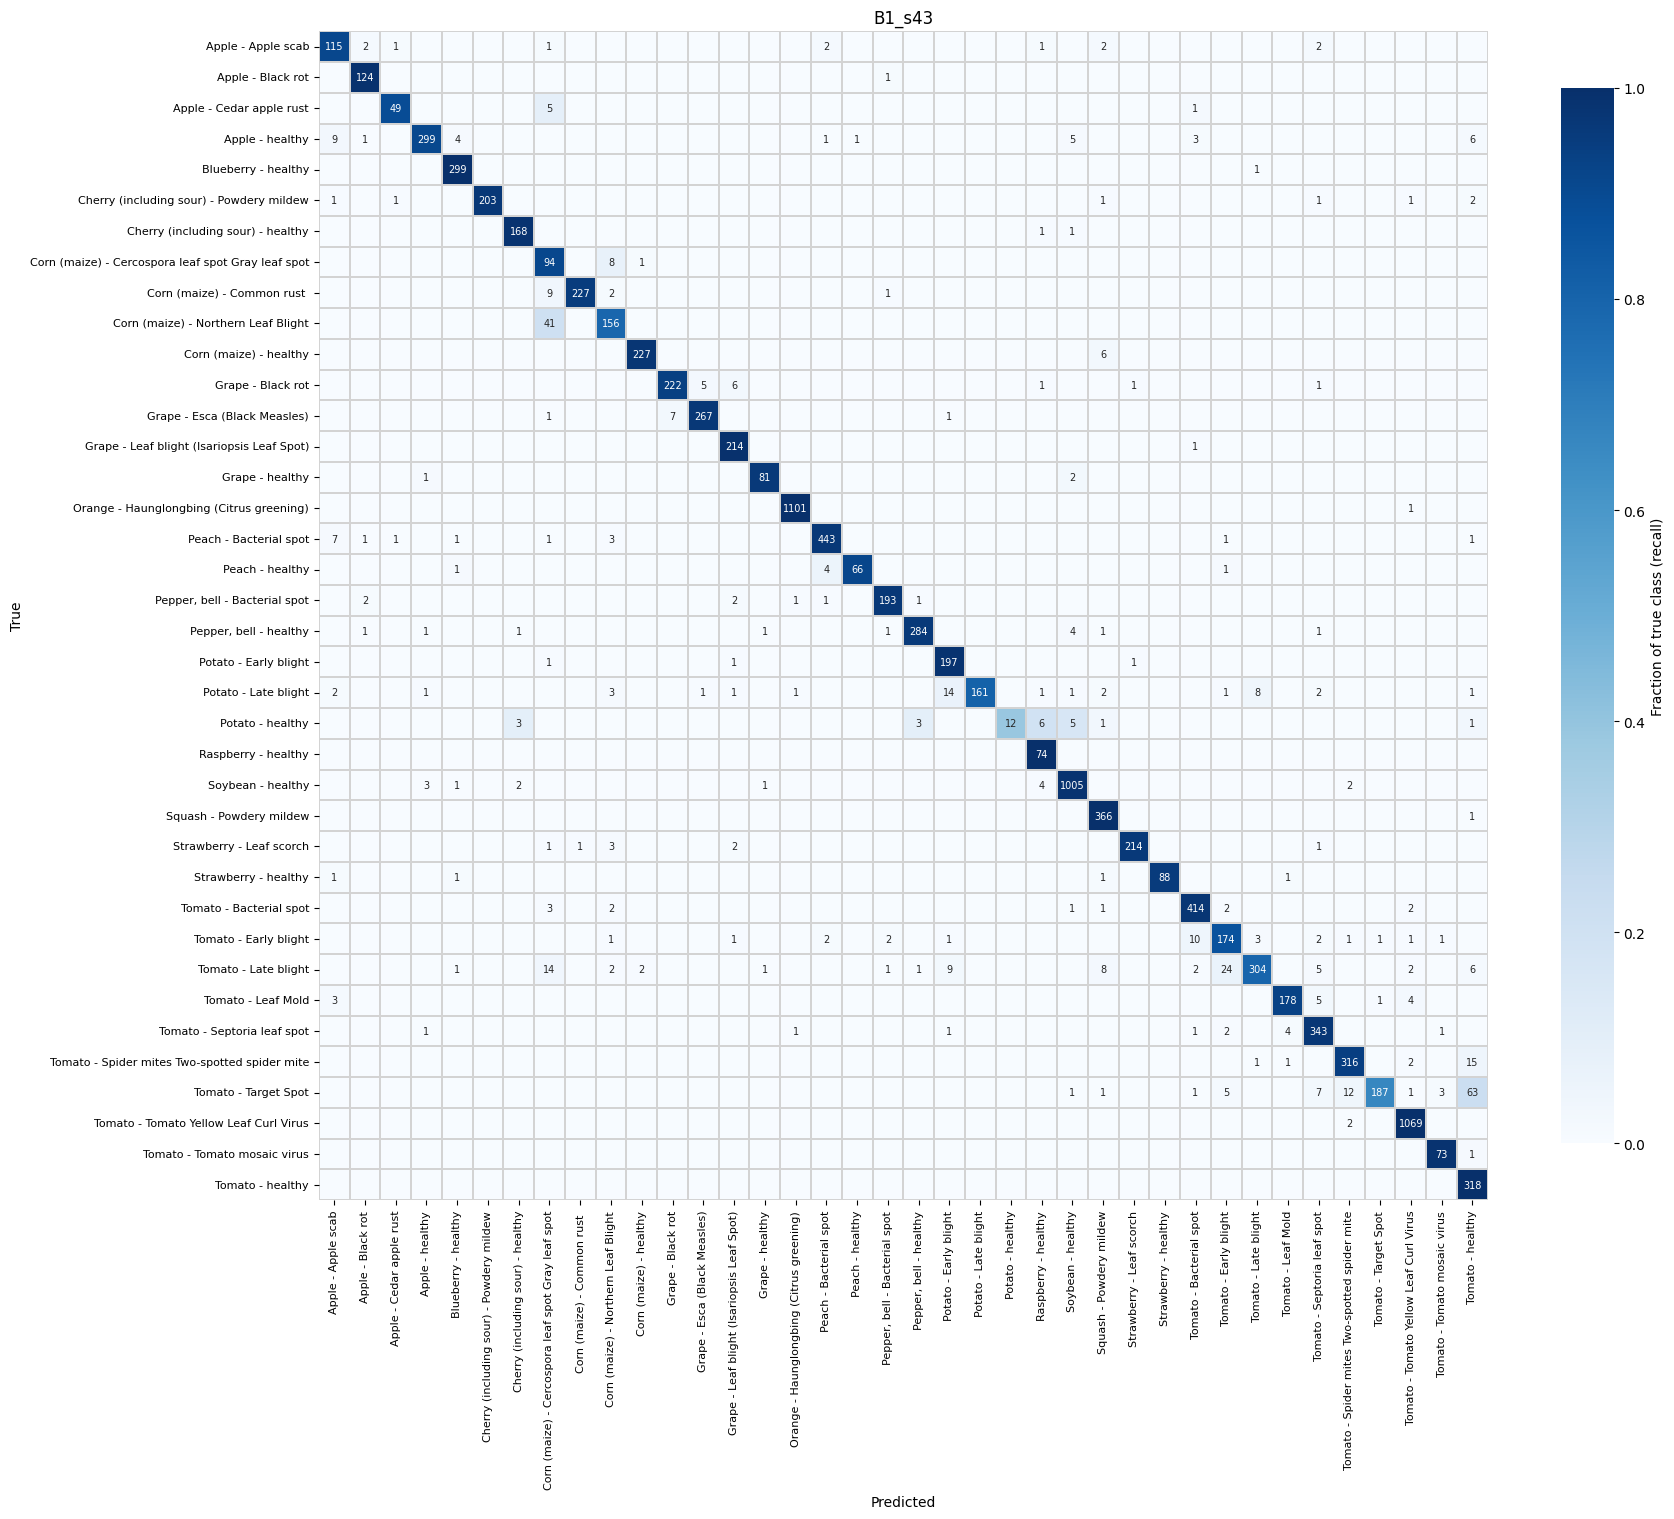


Top 10 confusions
count  % of true  total  true -> predicted
   63      22.4%    281  Tomato___Target_Spot -> Tomato___healthy
   41      20.8%    197  Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   24       6.3%    382  Tomato___Late_blight -> Tomato___Early_blight
   15       4.5%    335  Tomato___Spider_mites Two-spotted_spider_mite -> Tomato___healthy
   14       7.0%    200  Potato___Late_blight -> Potato___Early_blight
   14       3.7%    382  Tomato___Late_blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   12       4.3%    281  Tomato___Target_Spot -> Tomato___Spider_mites Two-spotted_spider_mite
   10       5.0%    200  Tomato___Early_blight -> Tomato___Bacterial_spot
    9       2.7%    329  Apple___healthy -> Apple___Apple_scab
    9       2.4%    382  Tomato___Late_blight -> Potato___Early_blight

Watch list (lowest 5 recall)
precision  recall      f1  total  class -> most confused with
    1.000   0.387   0.558    

(<Functional name=functional, built=True>,
 {'accuracy': 0.950649082660675,
  'loss': 0.15462057292461395,
  'precision': 0.9547734260559082,
  'recall': 0.9465979337692261},
 array([[ 115,    2,    1, ...,    0,    0,    0],
        [   0,  124,    0, ...,    0,    0,    0],
        [   0,    0,   49, ...,    0,    0,    0],
        ...,
        [   0,    0,    0, ..., 1069,    0,    0],
        [   0,    0,    0, ...,    0,   73,    1],
        [   0,    0,    0, ...,    0,    0,  318]]))

In [17]:
evaluate_experiment("B1_s43", n_epochs=3)

Currently, the model with seed 43 has `M` = 0.1546, which is in the unclear range. So we cannot conclude that BatchNorm is working. As `B1` and `B1_s43` show that unstable training, we will need to run more experiments with different approaches.

When you add BatchNormalization, the model's training dynamics become more sensitive to mini-batch statistics, moving statistics, batch size, learning rate, and random seed, which may be why the validation loss fluctuation got larger in your experiment.

In [57]:
# Fixed colour per run, so a run keeps its colour whichever runs are plotted together.
# Add new runs here (next free colours: "#e87ba4", "#008300").
RUN_COLORS = {
  "B0":     "#2a78d6",
  "B1":     "#eb6834",
  "B1_s43": "#1baf7a",
  "B2":     "#eda100",
  "B1m":    "#e87ba4",
  "B1m_rlr": "#008300",
  "B0_rlr":  "#7a5195",
  "B1m_rlr_s43": "#e90fb6",
  "B2_d05":  "#00ffff",
}

def plot_val_curves(run_names):
  missing = [r for r in run_names if r not in RUN_COLORS]
  assert not missing, f"Add a colour to RUN_COLORS for: {missing}"

  fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))
  panels = [(ax_loss, "val_loss", "Validation loss"),
            (ax_acc, "val_accuracy", "Validation accuracy")]

  for run_name in run_names:
    with open(f"history_{run_name}.json") as f:
      hist = json.load(f)
    epochs = np.arange(1, len(hist["val_loss"]) + 1)
    best = int(np.argmin(hist["val_loss"]))   # the epoch the checkpoint keeps
    color = RUN_COLORS[run_name]

    for ax, key, _ in panels:
      ax.plot(epochs, hist[key], color=color, linewidth=2, label=run_name)
      # Best epoch: same epoch on both panels, ringed so it stands out on the line
      ax.plot(epochs[best], hist[key][best], "o", color=color, markersize=9,
              markeredgecolor="white", markeredgewidth=2, zorder=3)
      # Direct label at the end of each line
      ax.annotate(run_name, (epochs[-1], hist[key][-1]), xytext=(6, 0),
                  textcoords="offset points", va="center", fontsize=9, color="#444")

  for ax, _, title in panels:
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.grid(True, color="#e5e5e5", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
      ax.spines[side].set_visible(False)
    ax.margins(x=0.08)   # room for the end-of-line labels

  ax_loss.set_ylabel("Categorical cross-entropy")
  ax_acc.set_ylabel("Accuracy")

  # One legend for both panels, plus a key for the best-epoch marker
  handles, labels = ax_loss.get_legend_handles_labels()
  handles.append(plt.Line2D([], [], marker="o", color="#888", linestyle="",
                            markersize=9, markeredgecolor="white", markeredgewidth=2))
  labels.append("best epoch (min val_loss)")
  fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False)

  fig.tight_layout(rect=(0, 0, 1, 0.93))
  plt.show()

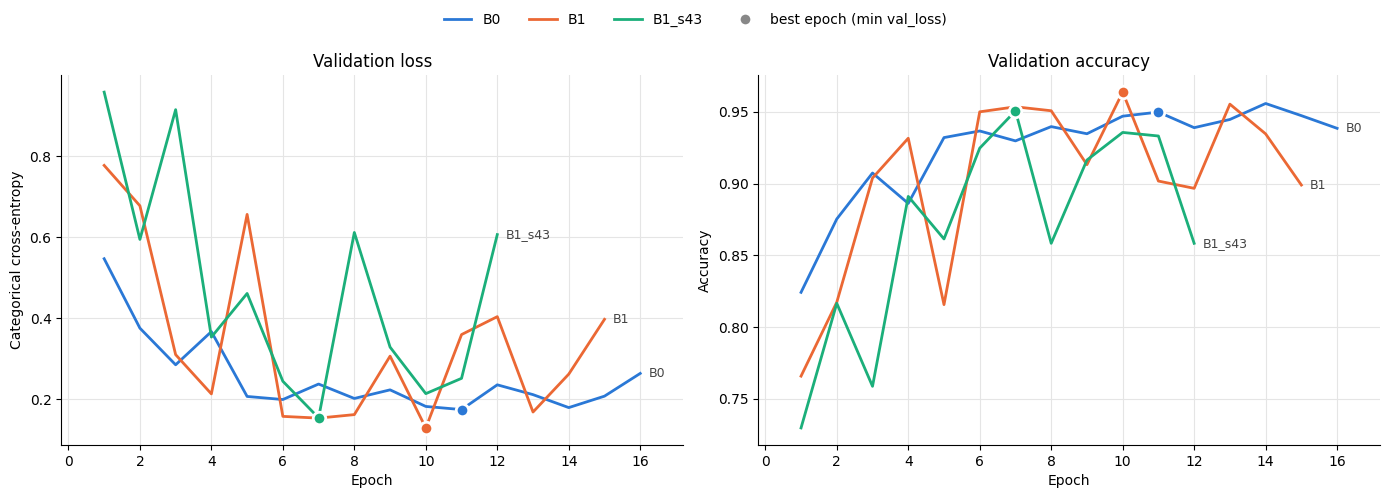

In [19]:
plot_val_curves(["B0", "B1", "B1_s43"])

Finding the reason for the unstable training

In [20]:
# Step 1: Probe dataset
PROBE_BATCHES = 32   # 32 x 32 = 1,024 train images
PROBE_SEED = 0

probe_raw = tf.keras.utils.image_dataset_from_directory(
  TRAIN_DIR,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  label_mode="categorical",
  shuffle=True,        # shuffle=False would give the first 1,024 files = Apple classes only
  seed=PROBE_SEED,
)
# take() before prepare(), so the cache inside prepare() holds exactly these 1,024 images
probe_ds = prepare(probe_raw.take(PROBE_BATCHES), training=False)

# Read it fully once: fills the cache, and checks the classes are mixed and the set is fixed
probe_labels = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in probe_ds])
again = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in probe_ds])
assert np.array_equal(probe_labels, again), "probe set changes between reads"
print(f"probe: {len(probe_labels)} images, {len(np.unique(probe_labels))}/{len(class_names)} classes")


Found 43444 files belonging to 38 classes.
probe: 1024 images, 38/38 classes


In [21]:
# Step 2: Callback (put it in the cell with `EpochTimer`)
class TrainProbe(tf.keras.callbacks.Callback):
  # Adds "probe_loss" / "probe_accuracy": a fixed set of TRAIN images scored in
  # inference mode (BN moving stats), to separate "BN stats lag" from "val generalisation"
  def __init__(self, probe_ds):
    super().__init__()
    self.probe_ds = probe_ds

  def on_epoch_end(self, epoch, logs=None):
    total_loss, total_correct, n = 0.0, 0, 0
    for x, y in self.probe_ds:
      p = self.model(x, training=False)   # never training=True: that would update BN moving stats
      total_loss += float(tf.reduce_sum(tf.keras.losses.categorical_crossentropy(y, p)))
      total_correct += int(tf.reduce_sum(tf.cast(tf.equal(tf.argmax(p, 1), tf.argmax(y, 1)), tf.int32)))
      n += int(y.shape[0])
    logs["probe_loss"] = total_loss / n           # per-image mean, same loss as compile()
    logs["probe_accuracy"] = total_correct / n

### Prediction (written before running B1_probe)
Epoch 5 reference: train loss 0.114, val_loss 0.657

1. My predicted epoch-5 probe_loss: 0.2 - 0.4. Reason: the model is unstable, so the probe loss will be 0.2-0.4 in epoch-5.

2. Decision rule (epoch 5 probe_loss):
   - | > 0.4  → (A) BN moving stats lag the weights → fix BN momentum, no need to re-run B0
   - | < 0.2  → (B) real generalisation instability → fix learning rate, re-run B0 too
   - 0.2–0.4 → both contribute


In [22]:
# Step 3: Run and check
run_experiment("B1_probe", build_bn_model, epochs=6, extra_callbacks=[TrainProbe(probe_ds)])

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
Epoch 1/6
   1358/Unknown 219s 160ms/step - accuracy: 0.6576 - loss: 1.2588 - precision: 0.8568 - recall: 0.5382

/Users/myomyataung/workspace/projects/python/-practice-project--plant-disease-classifier/.venv/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 232s 170ms/step - accuracy: 0.6576 - loss: 1.2584 - precision: 0.8568 - recall: 0.5383 - val_accuracy: 0.7659 - val_loss: 0.7776 - val_precision: 0.8185 - val_recall: 0.7331 - epoch_time: 230.5645 - probe_loss: 0.7851 - probe_accuracy: 0.7695
Epoch 2/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 232s 171ms/step - accuracy: 0.8992 - loss: 0.3172 - precision: 0.9236 - recall: 0.8790 - val_accuracy: 0.8173 - val_loss: 0.6779 - val_precision: 0.8418 - val_recall: 0.7985 - epoch_time: 230.1514 - probe_loss: 0.5828 - probe_accuracy: 0.8359
Epoch 3/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 237s 175ms/step - accuracy: 0.9319 - loss: 0.2120 - precision: 0.9447 - recall: 0.9221 - val_accuracy: 0.9039 - val_loss: 0.3106 - val_precision: 0.9184 - val_recall: 0.8927 - epoch_time: 235.5877 - probe_loss: 0.3102 - probe_accuracy: 0.9092
Epoch 4/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 251s 185ms/step - accuracy: 0.9499 - loss: 0.1490 - precision: 0.9562 - recall: 0.9435 - val_accuracy: 0.9316 - val_l

(<Functional name=functional, built=True>,
 <keras.src.callbacks.history.History at 0x3286561c0>)

In [23]:
# Built-in check: if the probe doesn't touch training, val_loss must match B1 exactly
with open("history_B1.json") as f:
  ref = json.load(f)
with open("history_B1_probe.json") as f:
  probe = json.load(f)

ref_vl, new_vl = np.array(ref["val_loss"][:6]), np.array(probe["val_loss"])
print(f"{'epoch':>5}{'B1':>10}{'B1_probe':>10}{'diff':>12}")
for e, (a, b) in enumerate(zip(ref_vl, new_vl), 1):
  print(f"{e:5d}{a:10.4f}{b:10.4f}{b - a:12.2e}")
print("identical" if np.array_equal(ref_vl, new_vl) else
      f"NOT identical (max |diff| = {np.abs(new_vl - ref_vl).max():.2e}) — don't trust the probe")

epoch        B1  B1_probe        diff
    1    0.7776    0.7776    0.00e+00
    2    0.6779    0.6779    0.00e+00
    3    0.3106    0.3106    0.00e+00
    4    0.2137    0.2137    0.00e+00
    5    0.6567    0.6567    0.00e+00
    6    0.1583    0.1583    0.00e+00
identical


In [24]:
# Step 4: Read the result
log_history("history_B1_probe.json")

history_B1_probe.json  (6 epochs)
epoch  split   accuracy       loss  precision     recall epoch_time probe_lossprobe_accuracy
    1  train     0.7777     0.7512     0.8816     0.7064   230.5645     0.7851     0.7695
       val       0.7659     0.7776     0.8185     0.7331                                 
    2  train     0.9119     0.2743     0.9316     0.8965   230.1514     0.5828     0.8359
       val       0.8173     0.6779     0.8418     0.7985                                 
    3  train     0.9405     0.1843     0.9511     0.9321   235.5877     0.3102     0.9092
       val       0.9039     0.3106     0.9184     0.8927                                 
    4  train     0.9546     0.1357     0.9611     0.9494   248.8733     0.1358     0.9502
       val       0.9316     0.2137     0.9394     0.9255                                 
    5  train     0.9614     0.1138     0.9653     0.9575   270.7725     0.5564     0.8262
       val       0.8157     0.6567     0.8332     0.8059       

{'accuracy': [0.7777138352394104,
  0.9118635654449463,
  0.9405211210250854,
  0.9545621871948242,
  0.9613755345344543,
  0.9727925658226013],
 'loss': [0.7512056827545166,
  0.27427470684051514,
  0.18428273499011993,
  0.13570420444011688,
  0.1137545257806778,
  0.08253418654203415],
 'precision': [0.8815672397613525,
  0.9316366314888,
  0.9511203765869141,
  0.9610652923583984,
  0.9653291702270508,
  0.9758408069610596],
 'recall': [0.7064266800880432,
  0.8965104222297668,
  0.9320734739303589,
  0.9494291543960571,
  0.9574854969978333,
  0.9697311520576477],
 'val_accuracy': [0.7658594846725464,
  0.8173280358314514,
  0.9038762450218201,
  0.9315900802612305,
  0.8156707286834717,
  0.9500045776367188],
 'val_loss': [0.7775764465332031,
  0.6779298782348633,
  0.31061115860939026,
  0.21374297142028809,
  0.6566657423973083,
  0.15829461812973022],
 'val_precision': [0.8184621930122375,
  0.8417936563491821,
  0.9183557629585266,
  0.9394392371177673,
  0.8332222700119019,


In [27]:
def build_bn_m09_model(n_classes):
  return build_bn_model(n_classes, bn_momentum=0.9)

## B1m: BN momentum 0.99 → 0.9

B1_probe showed epoch-5 probe_loss = 0.556 (> 0.4) → case (A): BN moving stats lag the weights.
B1m tests the fix: momentum 0.9 makes the moving stats follow the last ~10 batches instead of ~100.

### Decision rule
From epoch 3 on, every epoch must have **probe_loss < 2 × train loss**.

Reference (B1_probe, momentum 0.99):

| epoch | train loss | probe_loss | ratio | rule |
|---|---|---|---|---|
| 3 | 0.184 | 0.310 | 1.68 | ok |
| 4 | 0.136 | 0.136 | 1.00 | ok |
| 5 | 0.114 | 0.556 | 4.89 | **FAIL** |
| 6 | 0.083 | 0.085 | 1.03 | ok |

- PASS → BN stats lag was the cause; momentum 0.9 fixes it → B1m becomes the new BN baseline (confirm with seed 43)
- FAIL → momentum alone is not enough → look at learning rate next

### Prediction (written before running B1m)
1. PASS or FAIL: PASS
2. Highest ratio from epoch 3 on: 1.68 - 1.99
3. Reason: I don't know.


In [29]:
run_experiment("B1m", build_bn_m09_model, extra_callbacks=[TrainProbe(probe_ds)])

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
Epoch 1/30
   1358/Unknown 144s 105ms/step - accuracy: 0.6576 - loss: 1.2588 - precision: 0.8568 - recall: 0.5382

/Users/myomyataung/workspace/projects/python/-practice-project--plant-disease-classifier/.venv/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 154s 112ms/step - accuracy: 0.6576 - loss: 1.2584 - precision: 0.8568 - recall: 0.5383 - val_accuracy: 0.8067 - val_loss: 0.6215 - val_precision: 0.8575 - val_recall: 0.7766 - epoch_time: 152.7753 - probe_loss: 0.5897 - probe_accuracy: 0.8145
Epoch 2/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 199s 147ms/step - accuracy: 0.8992 - loss: 0.3172 - precision: 0.9236 - recall: 0.8790 - val_accuracy: 0.8867 - val_loss: 0.3587 - val_precision: 0.9040 - val_recall: 0.8735 - epoch_time: 197.6138 - probe_loss: 0.2995 - probe_accuracy: 0.9014
Epoch 3/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 219s 161ms/step - accuracy: 0.9319 - loss: 0.2120 - precision: 0.9447 - recall: 0.9221 - val_accuracy: 0.9386 - val_loss: 0.1894 - val_precision: 0.9482 - val_recall: 0.9308 - epoch_time: 216.9581 - probe_loss: 0.1546 - probe_accuracy: 0.9424
Epoch 4/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 230s 169ms/step - accuracy: 0.9499 - loss: 0.1490 - precision: 0.9562 - recall: 0.9435 - val_accuracy: 0.9367 - va

2026-10-07 13:22:06.011166: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 346s 255ms/step - accuracy: 0.9892 - loss: 0.0332 - precision: 0.9897 - recall: 0.9886 - val_accuracy: 0.9663 - val_loss: 0.1148 - val_precision: 0.9680 - val_recall: 0.9651 - epoch_time: 343.9062 - probe_loss: 0.0290 - probe_accuracy: 0.9912
Epoch 15/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 343s 253ms/step - accuracy: 0.9916 - loss: 0.0277 - precision: 0.9920 - recall: 0.9911 - val_accuracy: 0.9383 - val_loss: 0.2319 - val_precision: 0.9406 - val_recall: 0.9353 - epoch_time: 340.7670 - probe_loss: 0.1319 - probe_accuracy: 0.9551
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 10.
[B1m] epochs run: 15, best epoch: 10


(<Functional name=functional, built=True>,
 <keras.src.callbacks.history.History at 0x108258df0>)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
[B1m] best epoch: 10 / 15
metric      evaluate   history
accuracy      0.9733    0.9733
loss          0.0894    0.0894
precision     0.9748    0.9748
recall        0.9719    0.9719

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      1.000     0.794     0.885       126
                                 Apple___Black_rot      0.969     0.992     0.980       125
                          Apple___Cedar_apple_rust      0.948     1.000     0.973        55
                                   Apple___healthy      0.978     0.967     0.972       329
                               Blueberry___healthy      0.980     0.987     0.983       300
          Cherry_(including_sour)___Powdery_mildew      1.000     0.990     0.995       210
                 Cherry_(including_sour)___healthy      0.977     0.994     0.985      

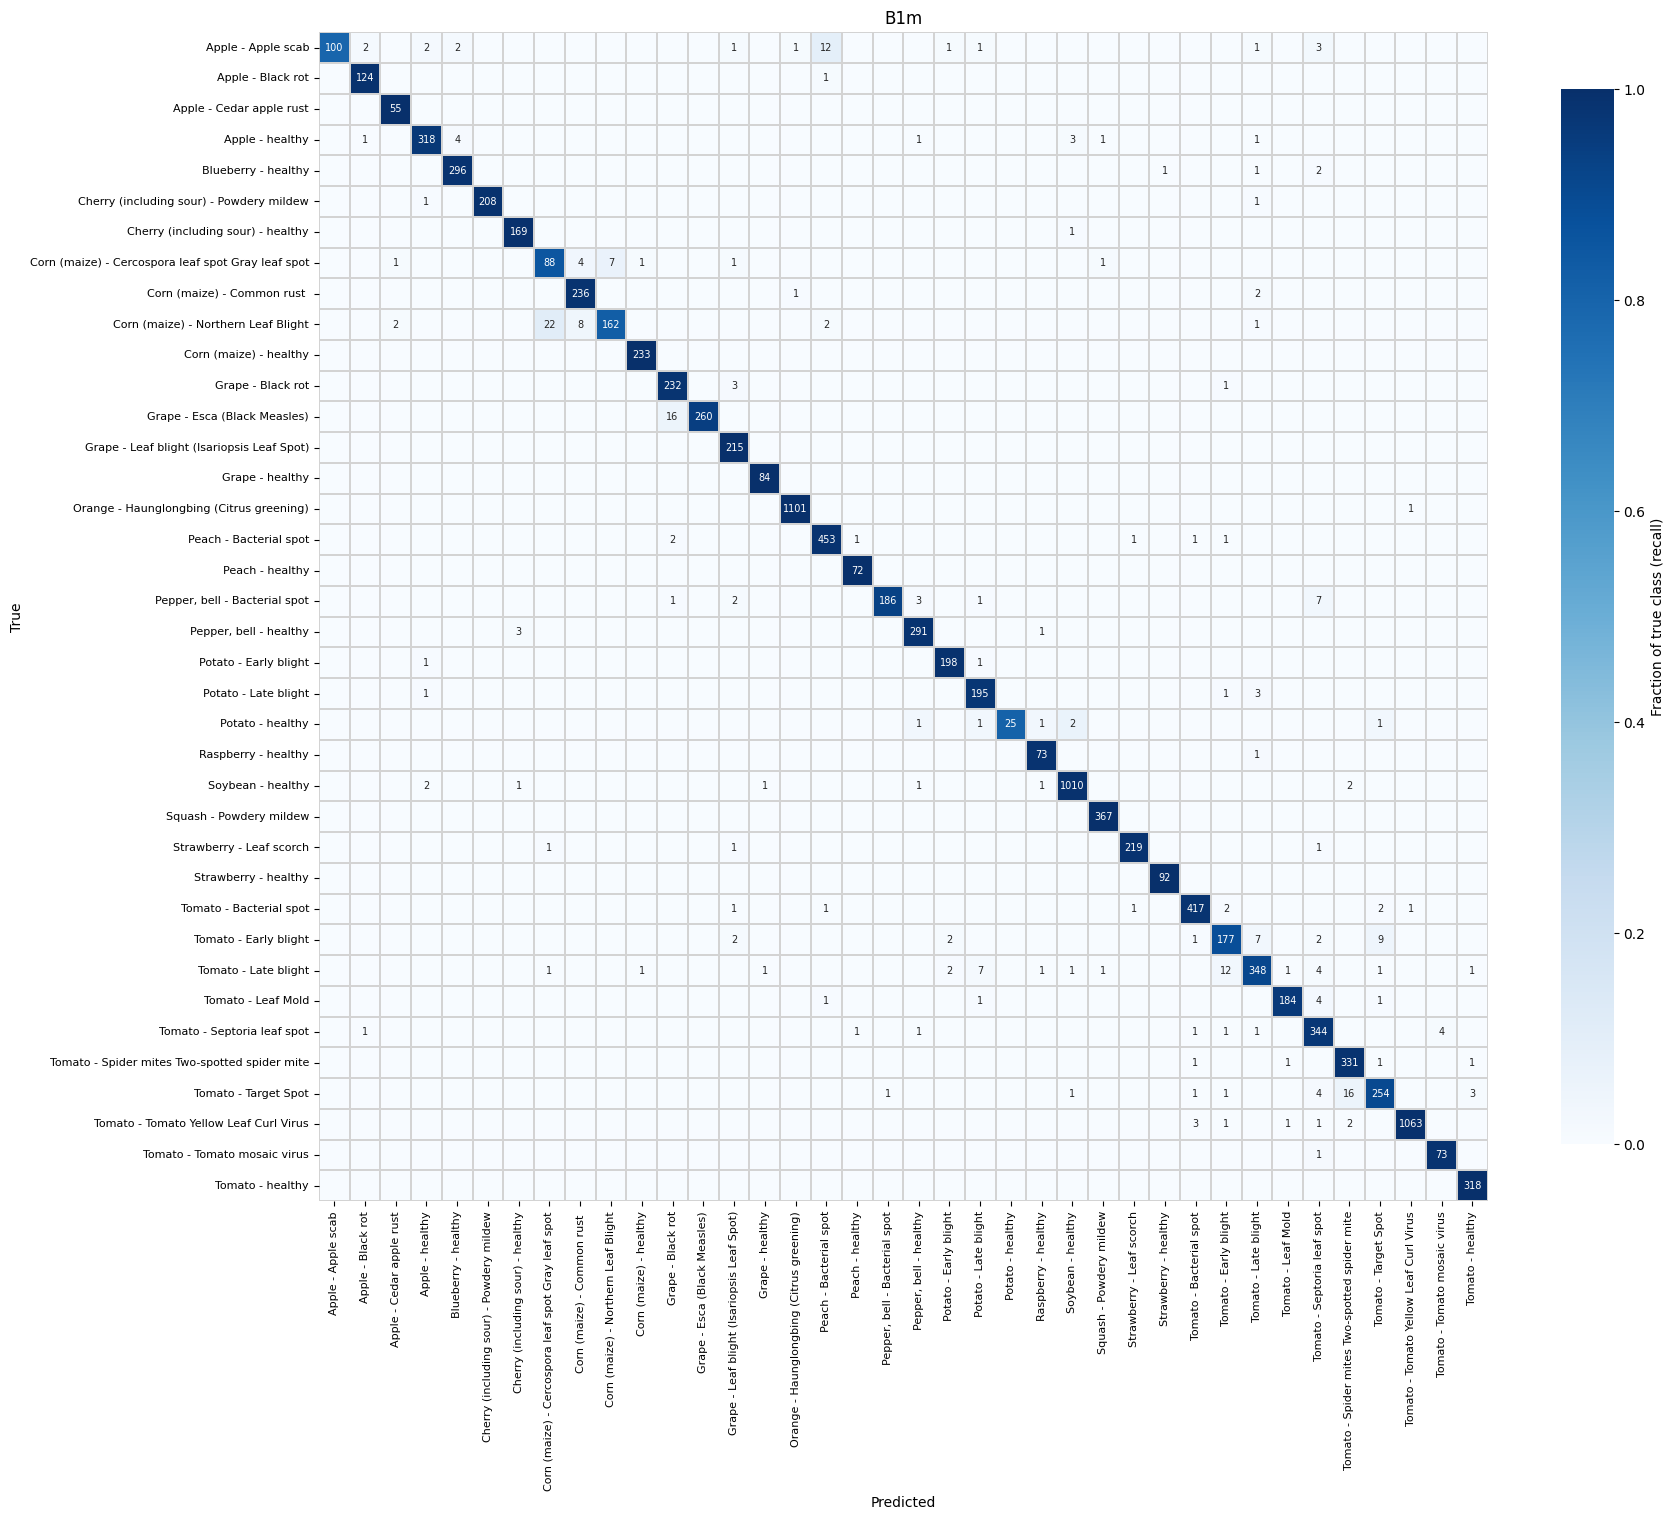


Top 10 confusions
count  % of true  total  true -> predicted
   22      11.2%    197  Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   16       5.8%    276  Grape___Esca_(Black_Measles) -> Grape___Black_rot
   16       5.7%    281  Tomato___Target_Spot -> Tomato___Spider_mites Two-spotted_spider_mite
   12       3.1%    382  Tomato___Late_blight -> Tomato___Early_blight
   12       9.5%    126  Apple___Apple_scab -> Peach___Bacterial_spot
    9       4.5%    200  Tomato___Early_blight -> Tomato___Target_Spot
    8       4.1%    197  Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Common_rust_
    7       1.8%    382  Tomato___Late_blight -> Potato___Late_blight
    7       3.5%    200  Pepper,_bell___Bacterial_spot -> Tomato___Septoria_leaf_spot
    7       3.5%    200  Tomato___Early_blight -> Tomato___Late_blight

Watch list (lowest 5 recall)
precision  recall      f1  total  class -> most confused with
    1.000   0.794   0.885    1

(<Functional name=functional, built=True>,
 {'accuracy': 0.973298966884613,
  'loss': 0.08939357846975327,
  'precision': 0.9747899174690247,
  'recall': 0.9719178676605225},
 array([[ 100,    2,    0, ...,    0,    0,    0],
        [   0,  124,    0, ...,    0,    0,    0],
        [   0,    0,   55, ...,    0,    0,    0],
        ...,
        [   0,    0,    0, ..., 1063,    0,    0],
        [   0,    0,    0, ...,    0,   73,    0],
        [   0,    0,    0, ...,    0,    0,  318]]))

In [30]:
evaluate_experiment("B1m")

In [31]:
def check_probe_rule(run_name, from_epoch=3, max_ratio=2.0):
  with open(f"history_{run_name}.json") as f:
    hist = json.load(f)
  loss, probe = np.array(hist["loss"]), np.array(hist["probe_loss"])
  ratio = probe / loss

  print(f"[{run_name}]  rule: probe_loss < {max_ratio} x loss from epoch {from_epoch}")
  print(f"{'epoch':>5}{'loss':>10}{'probe':>10}{'ratio':>8}")
  for e in range(len(loss)):
    flag = "" if e + 1 < from_epoch else ("ok" if ratio[e] < max_ratio else "FAIL")
    print(f"{e + 1:5d}{loss[e]:10.4f}{probe[e]:10.4f}{ratio[e]:8.2f}  {flag}")

  fails = [e + 1 for e in range(from_epoch - 1, len(loss)) if ratio[e] >= max_ratio]
  print("PASS\n" if not fails else f"FAIL at epochs {fails}\n")
  return not fails

In [32]:
check_probe_rule("B1_probe")

[B1_probe]  rule: probe_loss < 2.0 x loss from epoch 3
epoch      loss     probe   ratio
    1    0.7512    0.7851    1.05  
    2    0.2743    0.5828    2.13  
    3    0.1843    0.3102    1.68  ok
    4    0.1357    0.1358    1.00  ok
    5    0.1138    0.5564    4.89  FAIL
    6    0.0825    0.0846    1.03  ok
FAIL at epochs [5]



False

In [33]:
check_probe_rule("B1m")

[B1m]  rule: probe_loss < 2.0 x loss from epoch 3
epoch      loss     probe   ratio
    1    0.7512    0.5897    0.79  
    2    0.2743    0.2995    1.09  
    3    0.1843    0.1546    0.84  ok
    4    0.1357    0.1290    0.95  ok
    5    0.1138    0.2364    2.08  FAIL
    6    0.0825    0.0838    1.02  ok
    7    0.0769    0.0816    1.06  ok
    8    0.0603    0.0346    0.57  ok
    9    0.0558    0.0494    0.89  ok
   10    0.0445    0.0199    0.45  ok
   11    0.0435    0.2566    5.90  FAIL
   12    0.0332    0.1561    4.69  FAIL
   13    0.0374    0.0724    1.93  ok
   14    0.0325    0.0290    0.89  ok
   15    0.0281    0.1319    4.70  FAIL
FAIL at epochs [5, 11, 12, 15]



False

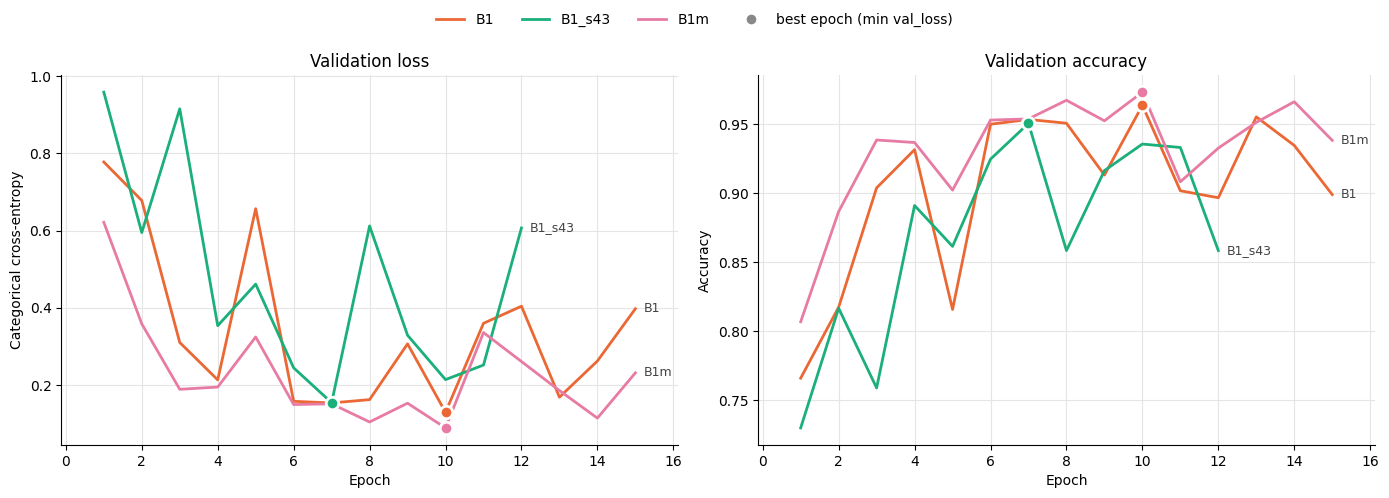

In [34]:
plot_val_curves(["B1", "B1_s43", "B1m"])

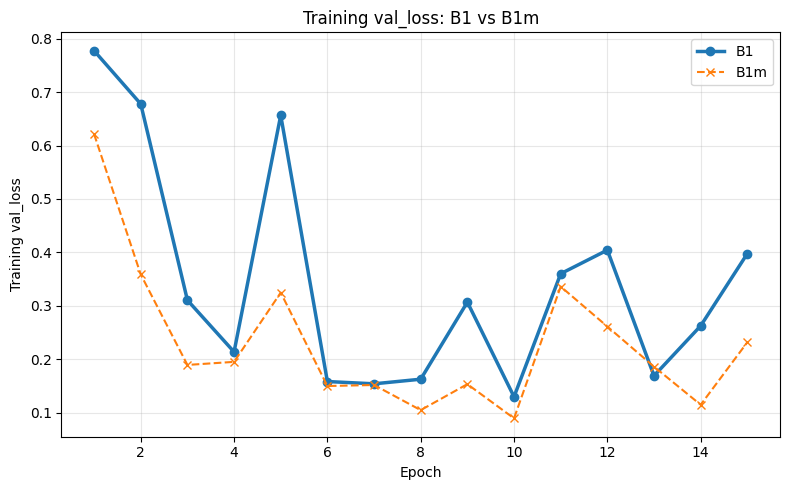

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

h_b1  = pd.read_csv("history_B1.csv")
h_b1m = pd.read_csv("history_B1m.csv")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(h_b1["epoch"] + 1,  h_b1["val_loss"],  marker="o", linewidth=2.5, label="B1")
ax.plot(h_b1m["epoch"] + 1, h_b1m["val_loss"], marker="x", linewidth=1.5,
        linestyle="--", label="B1m")

ax.set_title("Training val_loss: B1 vs B1m")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training val_loss")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## B1m_rlr / B0_rlr: ReduceLROnPlateau

B1m reduced the BN-lag spikes early on but still jumps late (epochs 11–15). ReduceLROnPlateau starts at
Adam's 0.001 and halves the LR when val_loss stops improving, so the late epochs train at a lower LR.

### Settings
| Setting | Value | Why |
|---|---|---|
| monitor | val_loss | same signal as EarlyStopping / ModelCheckpoint |
| factor | 0.5 | halve the LR on each cut |
| patience | 2 | see below |
| min_lr | 1e-5 | floor; 0.001 needs ~7 cuts to get there |

**Why patience 2:** it has to be smaller than EarlyStopping's 5.
- ≥ 5: EarlyStopping fires on the same epoch or earlier, so the LR is never cut and the run is a copy of B1m.
- 3: on B1m's curve the first cut would be at the end of epoch 13, and B1m stopped at 15. That leaves only 2 epochs at the lower LR.
- 1: one noisy epoch is enough to cut (B1m's epoch 4 rose by only 0.006).
- 2: cuts after two bad epochs in a row, and two cuts fit inside one EarlyStopping window.

### Why B1m_rlr must match B1m until the first cut
ReduceLROnPlateau only reads val_loss and writes the LR. Until the LR changes, the seed, initial weights,
data order and every optimizer step are the same as B1m, so loss / val_loss / probe_loss must be
bit-identical. If they're not, something else changed.

### Decision rule
probe_loss < 2 × train loss, applied from **the first epoch trained at the reduced LR** to the end.
(The original "from epoch 3" rule fails at epoch 5 no matter what, because epoch 5 is still B1m: ratio 2.08.)

- PASS → the late jumps were an LR problem → run B0_rlr
- FAIL → LR scheduling isn't enough → skip B0_rlr

### Prediction (written before running)
1. First LR cut: B1m val_loss is 0.1894 (best, epoch 3) → 0.1951 (wait 1) → 0.3248 (wait 2 = patience).
   → cut at the **end of epoch 5**, so **epoch 6** is the first epoch at LR 0.0005.
2. Under the original rule: FAIL at epoch 5 (certain).
3. Under the rule above: PASS / FAIL: PASS   Reason: I dont' know

In [38]:
def make_rlr(patience=2):
  # A new instance per run: the callback keeps its own wait/best counters.
  # Logs "learning_rate" (the LR used in that epoch) to history and the CSV by itself
  return tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=patience,   # must be < EarlyStopping patience (5), or EarlyStopping fires first
    min_lr=1e-5,
    verbose=1,
  )

In [39]:
run_experiment("B1m_rlr", build_bn_m09_model, extra_callbacks=[TrainProbe(probe_ds), make_rlr()])

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
Epoch 1/30
   1358/Unknown 146s 107ms/step - accuracy: 0.6576 - loss: 1.2588 - precision: 0.8568 - recall: 0.5382

/Users/myomyataung/workspace/projects/python/-practice-project--plant-disease-classifier/.venv/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 158s 115ms/step - accuracy: 0.6576 - loss: 1.2584 - precision: 0.8568 - recall: 0.5383 - val_accuracy: 0.8067 - val_loss: 0.6215 - val_precision: 0.8575 - val_recall: 0.7766 - epoch_time: 156.4476 - probe_loss: 0.5897 - probe_accuracy: 0.8145 - learning_rate: 0.0010
Epoch 2/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 212s 156ms/step - accuracy: 0.8992 - loss: 0.3172 - precision: 0.9236 - recall: 0.8790 - val_accuracy: 0.8867 - val_loss: 0.3587 - val_precision: 0.9040 - val_recall: 0.8735 - epoch_time: 210.2447 - probe_loss: 0.2995 - probe_accuracy: 0.9014 - learning_rate: 0.0010
Epoch 3/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 212s 156ms/step - accuracy: 0.9319 - loss: 0.2120 - precision: 0.9447 - recall: 0.9221 - val_accuracy: 0.9386 - val_loss: 0.1894 - val_precision: 0.9482 - val_recall: 0.9308 - epoch_time: 210.3526 - probe_loss: 0.1546 - probe_accuracy: 0.9424 - learning_rate: 0.0010
Epoch 4/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 209s 154ms/step - accuracy: 0.9499 - loss:

(<Functional name=functional, built=True>,
 <keras.src.callbacks.history.History at 0x3166cad00>)

In [48]:
def first_lr_cut_epoch(run_name):
  # 1-based epoch of the first epoch trained at a reduced LR, None = never cut
  with open(f"history_{run_name}.json") as f:
    hist = json.load(f)
  assert "learning_rate" in hist, f"history_{run_name}.json has no learning_rate: add an LR-logging callback"

  lr = np.array(hist["learning_rate"])
  dropped = np.flatnonzero(lr < lr[0])
  return int(dropped[0]) + 1 if len(dropped) else None

def check_identical_until_lr_drop(ref_run, new_run, keys=("loss", "val_loss")):
  # Before the first LR cut, the new run must reproduce ref_run exactly
  with open(f"history_{ref_run}.json") as f:
    ref = json.load(f)
  with open(f"history_{new_run}.json") as f:
    new = json.load(f)

  first_low = first_lr_cut_epoch(new_run)   # also checks that learning_rate was logged
  lr = np.array(new["learning_rate"])
  n_same = min((first_low or len(lr) + 1) - 1, len(ref["loss"]))

  print(f"{'epoch':>5}{'lr':>10}{ref_run + ' val':>14}{new_run + ' val':>14}")
  for e in range(len(lr)):
    ref_vl = f"{ref['val_loss'][e]:14.4f}" if e < len(ref["val_loss"]) else f"{'-':>14}"
    print(f"{e + 1:5d}{lr[e]:10.2e}{ref_vl}{new['val_loss'][e]:14.4f}")

  print(f"\nfirst epoch at reduced LR: {first_low if first_low else 'never'}")
  for key in keys:
    a, b = np.array(ref[key][:n_same]), np.array(new[key][:n_same])
    status = "identical" if np.array_equal(a, b) else \
             f"NOT identical (max |diff| = {np.abs(a - b).max():.2e}): don't trust this run"
    print(f"  {key:<11} epochs 1-{n_same}: {status}")
  return first_low

first_low = check_identical_until_lr_drop("B1m", "B1m_rlr", keys=("loss", "val_loss", "probe_loss"))


epoch        lr       B1m val   B1m_rlr val
    1  1.00e-03        0.6215        0.6215
    2  1.00e-03        0.3587        0.3587
    3  1.00e-03        0.1894        0.1894
    4  1.00e-03        0.1951        0.1951
    5  1.00e-03        0.3248        0.3248
    6  5.00e-04        0.1499        0.0870
    7  5.00e-04        0.1518        0.1076
    8  5.00e-04        0.1048        0.1068
    9  2.50e-04        0.1534        0.0527
   10  2.50e-04        0.0894        0.0715
   11  2.50e-04        0.3361        0.0630
   12  1.25e-04        0.2612        0.0518
   13  1.25e-04        0.1861        0.0537
   14  1.25e-04        0.1148        0.0534
   15  6.25e-05        0.2319        0.0520
   16  6.25e-05             -        0.0511
   17  6.25e-05             -        0.0488
   18  6.25e-05             -        0.0520
   19  6.25e-05             -        0.0499
   20  3.13e-05             -        0.0507
   21  3.13e-05             -        0.0492
   22  1.56e-05             -   

In [41]:
check_probe_rule("B1m_rlr")                         # original rule: expected FAIL at epoch 5

[B1m_rlr]  rule: probe_loss < 2.0 x loss from epoch 3
epoch      loss     probe   ratio
    1    0.7512    0.5897    0.79  
    2    0.2743    0.2995    1.09  
    3    0.1843    0.1546    0.84  ok
    4    0.1357    0.1290    0.95  ok
    5    0.1138    0.2364    2.08  FAIL
    6    0.0399    0.0340    0.85  ok
    7    0.0388    0.0435    1.12  ok
    8    0.0321    0.0452    1.41  ok
    9    0.0127    0.0048    0.37  ok
   10    0.0103    0.0074    0.72  ok
   11    0.0100    0.0089    0.89  ok
   12    0.0045    0.0013    0.30  ok
   13    0.0042    0.0015    0.35  ok
   14    0.0040    0.0017    0.42  ok
   15    0.0022    0.0009    0.40  ok
   16    0.0023    0.0007    0.29  ok
   17    0.0019    0.0004    0.24  ok
   18    0.0020    0.0008    0.41  ok
   19    0.0019    0.0005    0.28  ok
   20    0.0013    0.0005    0.35  ok
   21    0.0012    0.0003    0.24  ok
   22    0.0011    0.0003    0.26  ok
FAIL at epochs [5]



False

In [42]:
check_probe_rule("B1m_rlr", from_epoch=first_low)   # agreed rule: this one decides

[B1m_rlr]  rule: probe_loss < 2.0 x loss from epoch 6
epoch      loss     probe   ratio
    1    0.7512    0.5897    0.79  
    2    0.2743    0.2995    1.09  
    3    0.1843    0.1546    0.84  
    4    0.1357    0.1290    0.95  
    5    0.1138    0.2364    2.08  
    6    0.0399    0.0340    0.85  ok
    7    0.0388    0.0435    1.12  ok
    8    0.0321    0.0452    1.41  ok
    9    0.0127    0.0048    0.37  ok
   10    0.0103    0.0074    0.72  ok
   11    0.0100    0.0089    0.89  ok
   12    0.0045    0.0013    0.30  ok
   13    0.0042    0.0015    0.35  ok
   14    0.0040    0.0017    0.42  ok
   15    0.0022    0.0009    0.40  ok
   16    0.0023    0.0007    0.29  ok
   17    0.0019    0.0004    0.24  ok
   18    0.0020    0.0008    0.41  ok
   19    0.0019    0.0005    0.28  ok
   20    0.0013    0.0005    0.35  ok
   21    0.0012    0.0003    0.24  ok
   22    0.0011    0.0003    0.26  ok
PASS



True

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
[B1m_rlr] best epoch: 17 / 22
metric      evaluate   history
accuracy      0.9867    0.9867
loss          0.0488    0.0488
precision     0.9872    0.9872
recall        0.9862    0.9862

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.992     0.944     0.967       126
                                 Apple___Black_rot      0.992     1.000     0.996       125
                          Apple___Cedar_apple_rust      1.000     1.000     1.000        55
                                   Apple___healthy      0.988     0.982     0.985       329
                               Blueberry___healthy      0.983     0.990     0.987       300
          Cherry_(including_sour)___Powdery_mildew      0.995     1.000     0.998       210
                 Cherry_(including_sour)___healthy      1.000     0.988     0.994  

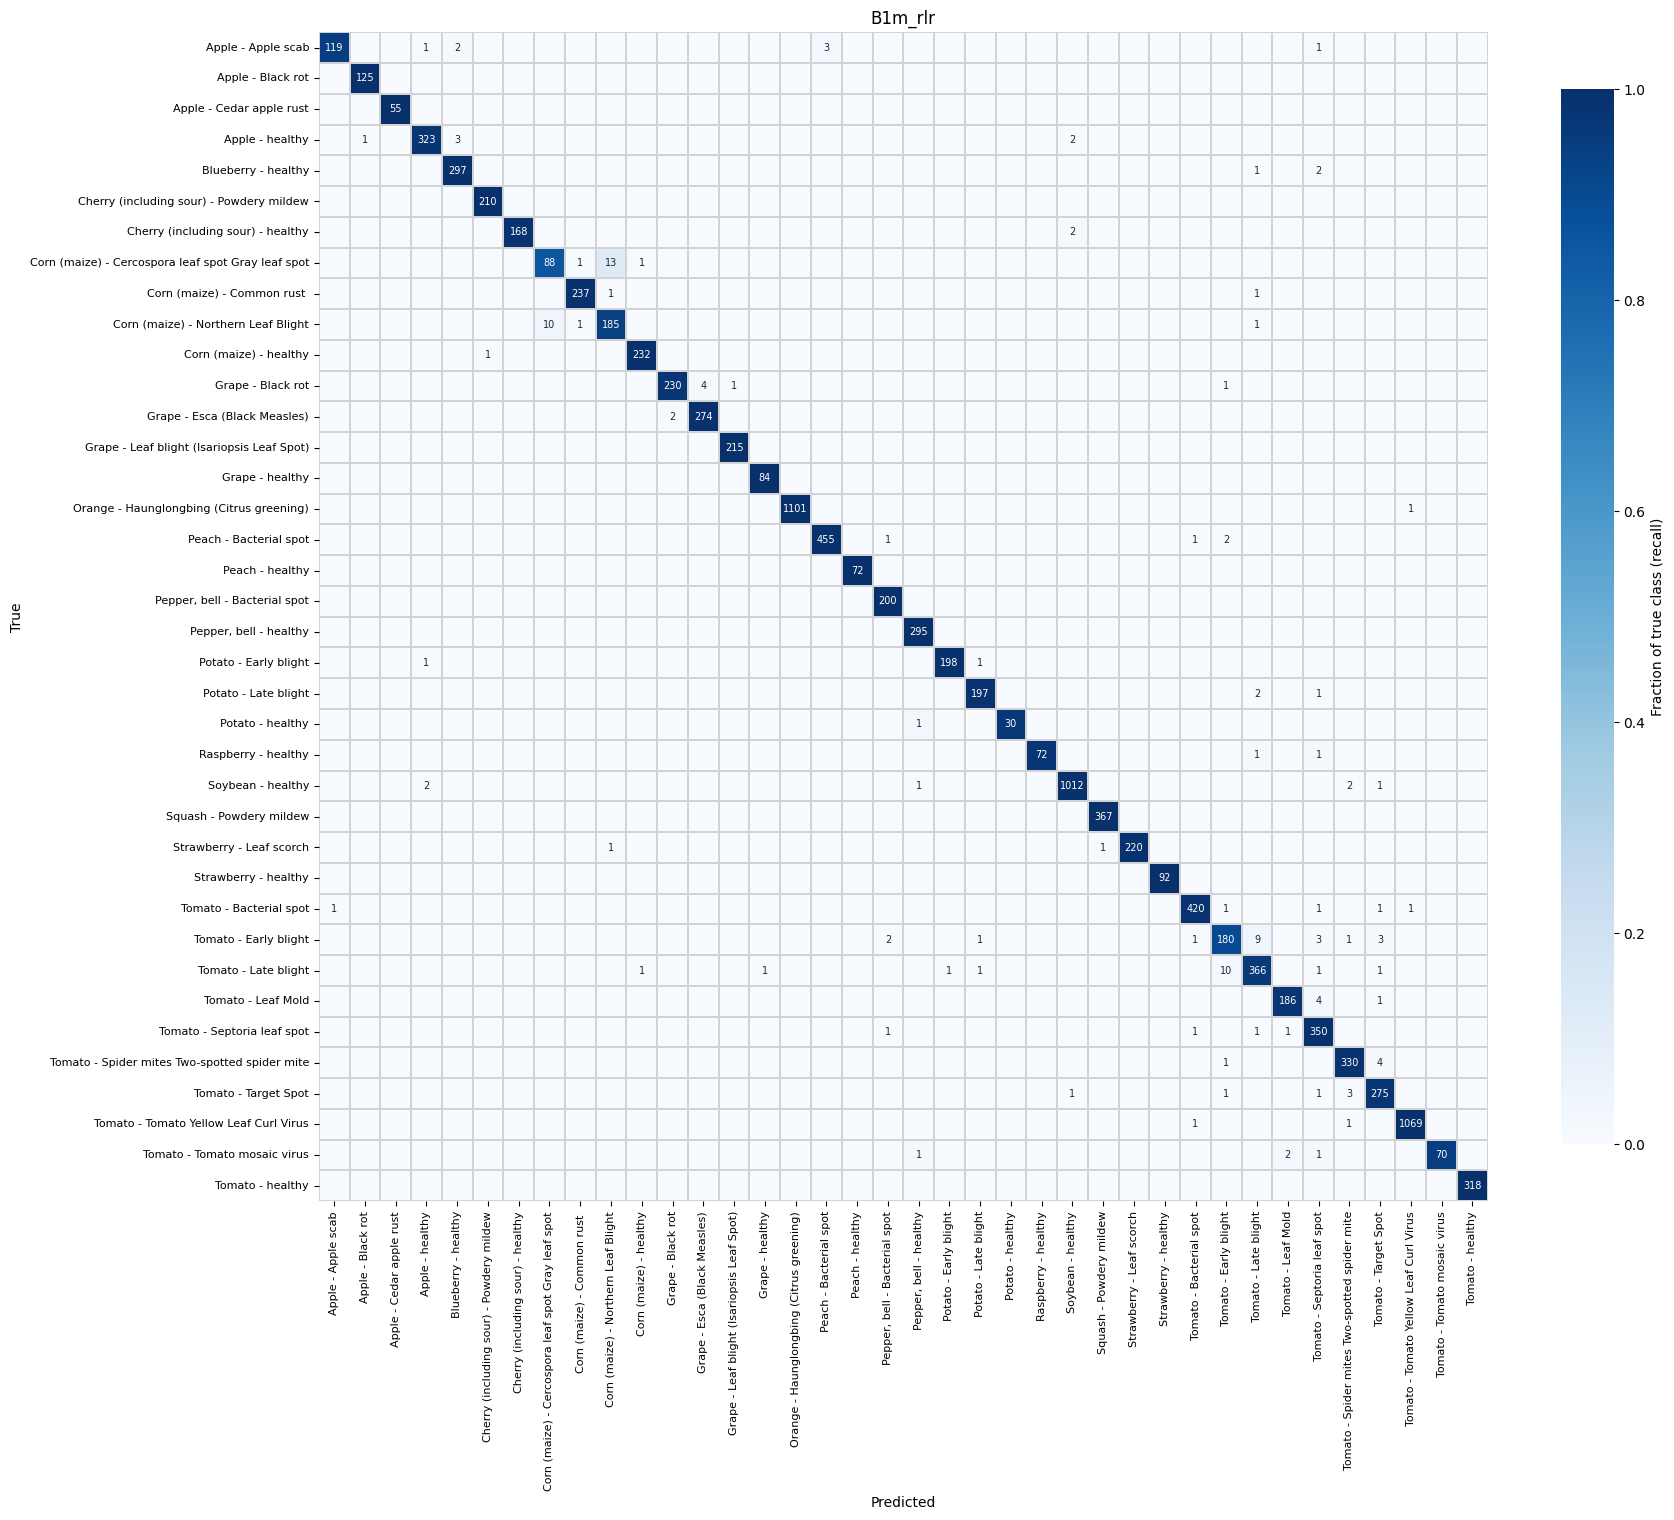


Top 10 confusions
count  % of true  total  true -> predicted
   13      12.6%    103  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Corn_(maize)___Northern_Leaf_Blight
   10       2.6%    382  Tomato___Late_blight -> Tomato___Early_blight
   10       5.1%    197  Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
    9       4.5%    200  Tomato___Early_blight -> Tomato___Late_blight
    4       1.7%    236  Grape___Black_rot -> Grape___Esca_(Black_Measles)
    4       2.1%    191  Tomato___Leaf_Mold -> Tomato___Septoria_leaf_spot
    4       1.2%    335  Tomato___Spider_mites Two-spotted_spider_mite -> Tomato___Target_Spot
    3       0.9%    329  Apple___healthy -> Blueberry___healthy
    3       1.5%    200  Tomato___Early_blight -> Tomato___Septoria_leaf_spot
    3       2.4%    126  Apple___Apple_scab -> Peach___Bacterial_spot

Watch list (lowest 5 recall)
precision  recall      f1  total  class -> most confused with
    0.898   0.854

(<Functional name=functional, built=True>,
 {'accuracy': 0.9867415428161621,
  'loss': 0.048791565001010895,
  'precision': 0.9871889352798462,
  'recall': 0.9861891269683838},
 array([[ 119,    0,    0, ...,    0,    0,    0],
        [   0,  125,    0, ...,    0,    0,    0],
        [   0,    0,   55, ...,    0,    0,    0],
        ...,
        [   0,    0,    0, ..., 1069,    0,    0],
        [   0,    0,    0, ...,    0,   70,    0],
        [   0,    0,    0, ...,    0,    0,  318]]))

In [43]:
evaluate_experiment("B1m_rlr")

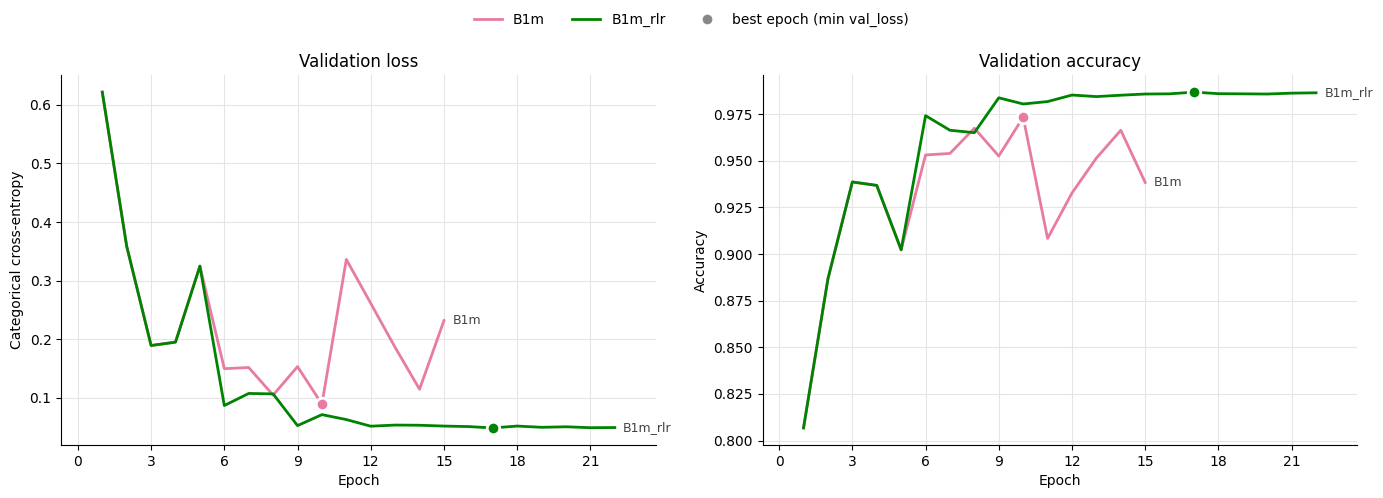

In [44]:
plot_val_curves(["B1m", "B1m_rlr"])

In [45]:
run_experiment("B0_rlr", build_model, extra_callbacks=[make_rlr()])

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
Epoch 1/30
   1357/Unknown 75s 54ms/step - accuracy: 0.4915 - loss: 1.8631 - precision: 0.7896 - recall: 0.3478

/Users/myomyataung/workspace/projects/python/-practice-project--plant-disease-classifier/.venv/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 82s 59ms/step - accuracy: 0.4918 - loss: 1.8620 - precision: 0.7897 - recall: 0.3481 - val_accuracy: 0.8242 - val_loss: 0.5473 - val_precision: 0.8927 - val_recall: 0.7704 - epoch_time: 81.5758 - learning_rate: 0.0010
Epoch 2/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 84s 62ms/step - accuracy: 0.8460 - loss: 0.4909 - precision: 0.8973 - recall: 0.8012 - val_accuracy: 0.8753 - val_loss: 0.3760 - val_precision: 0.9063 - val_recall: 0.8500 - epoch_time: 84.3424 - learning_rate: 0.0010
Epoch 3/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 102s 75ms/step - accuracy: 0.8955 - loss: 0.3230 - precision: 0.9224 - recall: 0.8744 - val_accuracy: 0.9074 - val_loss: 0.2856 - val_precision: 0.9276 - val_recall: 0.8927 - epoch_time: 101.7220 - learning_rate: 0.0010
Epoch 4/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 106s 78ms/step - accuracy: 0.9229 - loss: 0.2346 - precision: 0.9399 - recall: 0.9091 - val_accuracy: 0.8862 - val_loss: 0.3674 - val_precision: 0.9035 - val_recall: 0.8742 - epoch_time: 

(<Functional name=functional, built=True>,
 <keras.src.callbacks.history.History at 0x31313d340>)

epoch        lr        B0 val    B0_rlr val
    1  1.00e-03        0.5473        0.5473
    2  1.00e-03        0.3760        0.3760
    3  1.00e-03        0.2856        0.2856
    4  1.00e-03        0.3674        0.3674
    5  1.00e-03        0.2075        0.2075
    6  1.00e-03        0.1999        0.1999
    7  1.00e-03        0.2381        0.2381
    8  1.00e-03        0.2025        0.2025
    9  5.00e-04        0.2237        0.1656
   10  5.00e-04        0.1828        0.1929
   11  5.00e-04        0.1751        0.1920
   12  2.50e-04        0.2362        0.1288
   13  2.50e-04        0.2119        0.1658
   14  2.50e-04        0.1800        0.1501
   15  1.25e-04        0.2082        0.1333
   16  1.25e-04        0.2643        0.1394
   17  6.25e-05             -        0.1378

first epoch at reduced LR: 9
  loss        epochs 1-8: identical
  val_loss    epochs 1-8: identical
Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
[B0_rlr] best epoch:

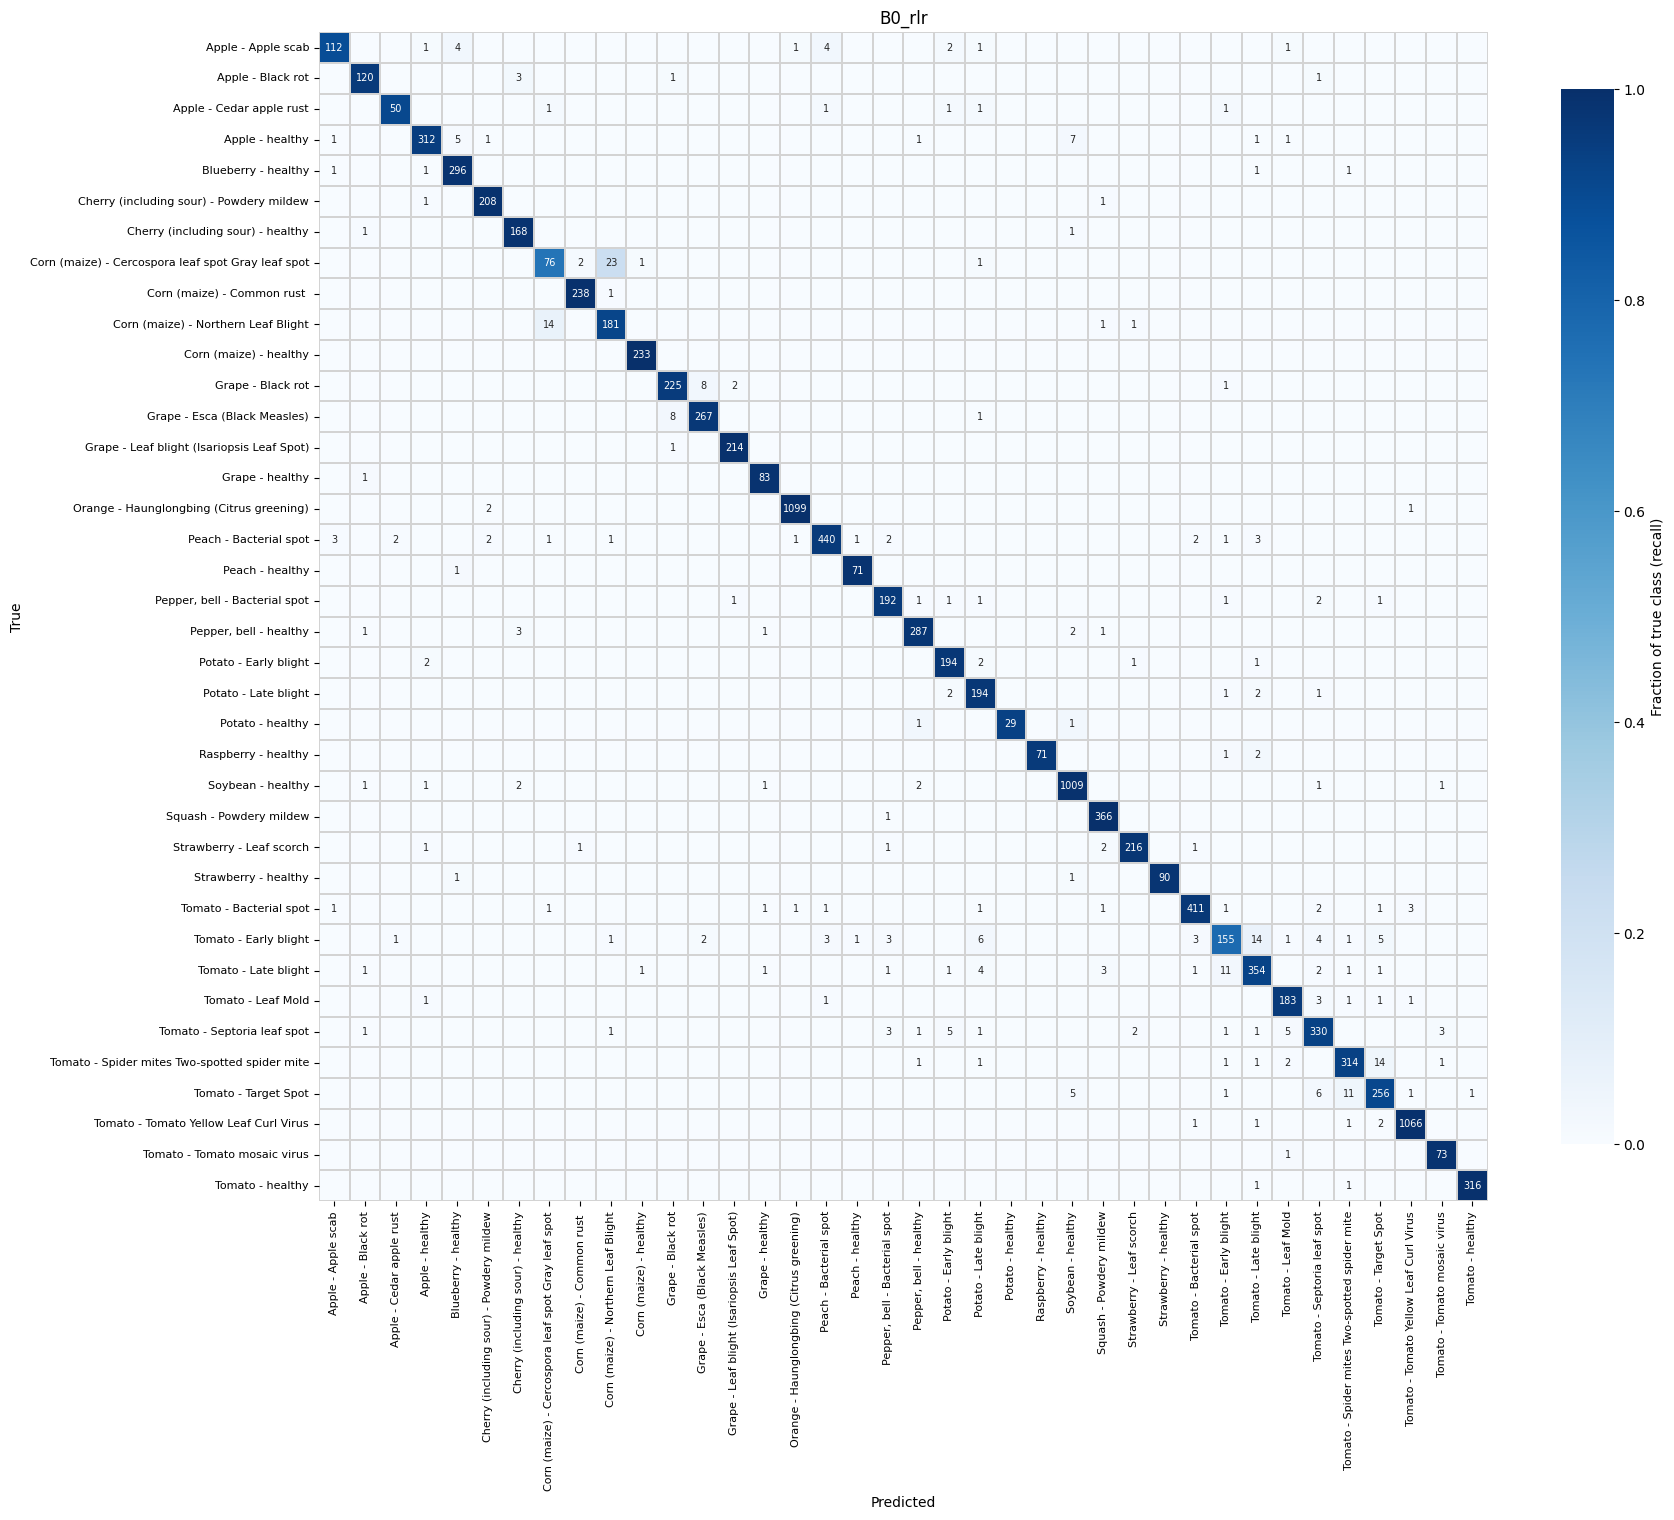


Top 10 confusions
count  % of true  total  true -> predicted
   23      22.3%    103  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Corn_(maize)___Northern_Leaf_Blight
   14       7.0%    200  Tomato___Early_blight -> Tomato___Late_blight
   14       4.2%    335  Tomato___Spider_mites Two-spotted_spider_mite -> Tomato___Target_Spot
   14       7.1%    197  Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   11       2.9%    382  Tomato___Late_blight -> Tomato___Early_blight
   11       3.9%    281  Tomato___Target_Spot -> Tomato___Spider_mites Two-spotted_spider_mite
    8       3.4%    236  Grape___Black_rot -> Grape___Esca_(Black_Measles)
    8       2.9%    276  Grape___Esca_(Black_Measles) -> Grape___Black_rot
    7       2.1%    329  Apple___healthy -> Soybean___healthy
    6       3.0%    200  Tomato___Early_blight -> Potato___Late_blight

Watch list (lowest 5 recall)
precision  recall      f1  total  class -> most confused with
 

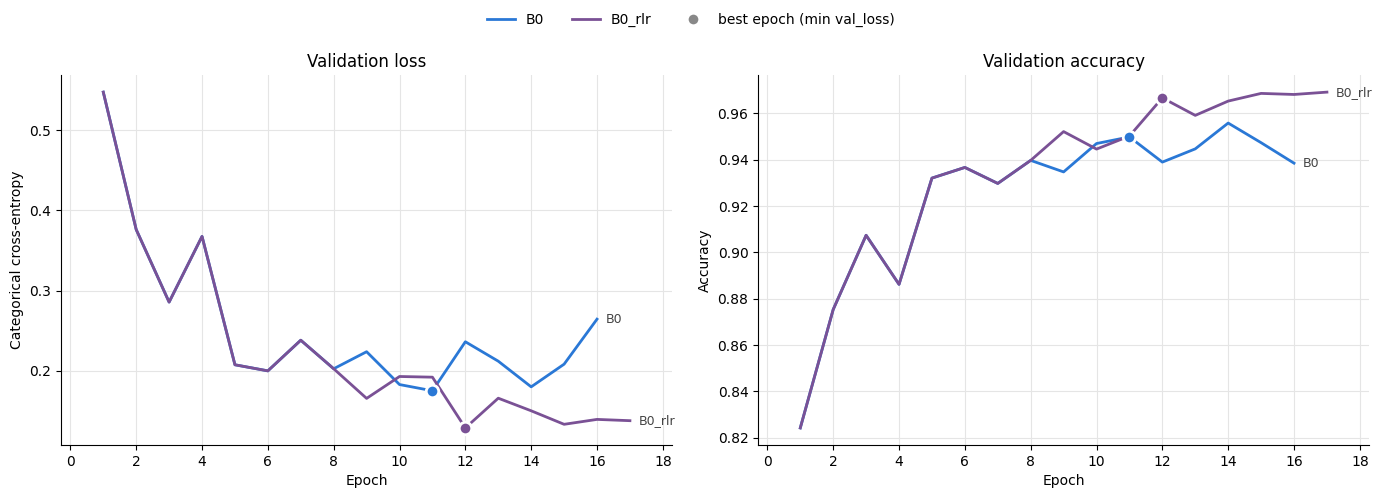

In [46]:
first_low_b0 = check_identical_until_lr_drop("B0", "B0_rlr")
evaluate_experiment("B0_rlr")
plot_val_curves(["B0", "B0_rlr"])

## Summary: why B1 was unstable, and how it was fixed

| Run | Change | Best val_loss | Val acc | Macro-F1 |
|---|---|---|---|---|
| B0 | baseline | 0.175 | 94.98% | 0.935 |
| B1 | + BatchNorm (momentum 0.99) | 0.130 | 96.37% | 0.945 |
| B1_s43 | B1, seed 43 | 0.155 | 95.06% | 0.926 |
| B1m | BN momentum 0.9 | 0.089 | 97.33% | 0.962 |
| B0_rlr | B0 + ReduceLROnPlateau | 0.129 | 96.67% | 0.955 |
| B1m_rlr | B1m + ReduceLROnPlateau | **0.049** | **98.67%** | **0.982** |

1. **B1:** adding BN made val_loss jump between epochs (e.g. 0.214 → 0.657 → 0.158), while train loss fell smoothly.
2. **B1_probe:** a fixed set of 1,024 *train* images scored in inference mode jumped together with val_loss
   (epoch 5: train loss 0.114, probe 0.556, val 0.657). The model fit the train images, so the jumps came from
   BN inference mode (moving mean/variance), not from generalisation.
3. **B1m:** momentum only changes the moving stats, which training mode writes but never reads, so B1m's weights
   are bit-identical to B1's at every epoch. With the same weights, momentum 0.9 lowered val_loss in 14 of 15 epochs,
   but jumps remained (epochs 5, 9, 11, 15).
4. **B1m_rlr:** halving the LR when val_loss plateaus slows the weight changes, so the moving stats keep up.
   From the first cut (epoch 6) the probe rule passed and val_loss settled at 0.049–0.072.

**Conclusion:** BN's moving stats fell behind weights that were changing too fast. Both a shorter averaging window
(momentum 0.9) and a lower LR were needed. Under the same LR schedule, BN beats no-BN by 0.08 val_loss
(0.129 → 0.049) and 2 accuracy points.

## Protocol for B2–B4

Fixed for every run from here on:

| Item | Setting |
|---|---|
| Data | PlantVillage (original), 128×128, batch 32, same `prepare()` pipeline |
| Seed | 42 |
| Base model | `build_bn_m09_model` (BN momentum 0.9, conv `use_bias=False`) |
| Optimizer | Adam, start LR 1e-3 |
| LR schedule | `make_rlr()`: ReduceLROnPlateau(val_loss, factor 0.5, patience 2, min_lr 1e-5), new instance per run |
| Stopping | EarlyStopping(val_loss, patience 5, restore best weights), max 30 epochs |
| Callbacks | EpochTimer, TrainProbe, make_rlr(), EarlyStopping, ModelCheckpoint, CSVLogger |
| Evaluation | `evaluate_experiment`, `check_probe_rule` from the first LR cut |

**Ablation chain:** B0_rlr → B1m_rlr → B2 (+Dropout) → B3 (+Augmentation) → B4 (+Residual blocks).
Each step adds exactly one change to the previous one.

If a run reaches 30 epochs without early stopping, note it: the cap may have cut it short.

## B1m_rlr_s43: is B1m_rlr's result seed luck?

B1 differed a lot between seeds (0.130 vs 0.155). B2–B4 all build on B1m_rlr, so confirm it with seed 43 first.

### Decision rule (best val_loss)
- **< 0.09**: confirmed, clearly better than B0_rlr (0.129) → continue to B2
- **0.09 – 0.129**: better than B0_rlr but less than seed 42 suggested → continue, note the spread
- **≥ 0.129**: no better than B0_rlr → stop and rethink before B2

Also required: probe rule PASS from the first LR cut.

Limitation: B0_rlr was run with seed 42 only.

### Prediction (written before running)
1. Best val_loss: 0.05
2. Probe rule PASS / FAIL: PASS
3. Reason: I hope the result is not seed luck, but I don't know.

## Known limitations (to fix before Part 6)

- **Val set reuse:** the val set drives EarlyStopping, checkpoint selection, LR cuts and our model choices,
  so val scores are optimistic. A separate held-out test set is needed before reporting final numbers.
- **Single seed:** except B1/B1_s43 (and B1m_rlr_s43), each result comes from one seed. Differences under
  ~1 accuracy point may be seed noise.
- **Timing:** epoch_time varies with machine temperature and load (152–344 s for the same model), so it is
  only a rough comparison.

In [49]:
run_experiment("B1m_rlr_s43", build_bn_m09_model, seed=43, extra_callbacks=[TrainProbe(probe_ds), make_rlr()])

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
Epoch 1/30
   1358/Unknown 140s 102ms/step - accuracy: 0.6582 - loss: 1.2664 - precision: 0.8437 - recall: 0.5440

/Users/myomyataung/workspace/projects/python/-practice-project--plant-disease-classifier/.venv/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 151s 110ms/step - accuracy: 0.6583 - loss: 1.2661 - precision: 0.8437 - recall: 0.5441 - val_accuracy: 0.7436 - val_loss: 0.8780 - val_precision: 0.7805 - val_recall: 0.7146 - epoch_time: 149.5222 - probe_loss: 0.8472 - probe_accuracy: 0.7402 - learning_rate: 0.0010
Epoch 2/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 227s 167ms/step - accuracy: 0.9032 - loss: 0.3010 - precision: 0.9258 - recall: 0.8860 - val_accuracy: 0.7558 - val_loss: 0.8855 - val_precision: 0.7949 - val_recall: 0.7323 - epoch_time: 225.2100 - probe_loss: 0.9026 - probe_accuracy: 0.7441 - learning_rate: 0.0010
Epoch 3/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 220s 162ms/step - accuracy: 0.9365 - loss: 0.1971 - precision: 0.9477 - recall: 0.9265 - val_accuracy: 0.9008 - val_loss: 0.3137 - val_precision: 0.9151 - val_recall: 0.8903 - epoch_time: 218.1417 - probe_loss: 0.2896 - probe_accuracy: 0.9023 - learning_rate: 0.0010
Epoch 4/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 217s 160ms/step - accuracy: 0.9483 - loss:

2026-10-07 20:29:08.715330: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 221s 163ms/step - accuracy: 0.9714 - loss: 0.0860 - precision: 0.9742 - recall: 0.9683 - val_accuracy: 0.9472 - val_loss: 0.1659 - val_precision: 0.9534 - val_recall: 0.9443 - epoch_time: 219.5486 - probe_loss: 0.1035 - probe_accuracy: 0.9668 - learning_rate: 0.0010
Epoch 7/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 224s 165ms/step - accuracy: 0.9719 - loss: 0.0826 - precision: 0.9748 - recall: 0.9695 - val_accuracy: 0.9681 - val_loss: 0.1006 - val_precision: 0.9711 - val_recall: 0.9663 - epoch_time: 222.2657 - probe_loss: 0.0545 - probe_accuracy: 0.9814 - learning_rate: 0.0010
Epoch 8/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 226s 166ms/step - accuracy: 0.9809 - loss: 0.0546 - precision: 0.9826 - recall: 0.9793 - val_accuracy: 0.9077 - val_loss: 0.3629 - val_precision: 0.9139 - val_recall: 0.9051 - epoch_time: 224.4484 - probe_loss: 0.2511 - probe_accuracy: 0.9277 - learning_rate: 0.0010
Epoch 9/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9793 - loss: 0

(<Functional name=functional, built=True>,
 <keras.src.callbacks.history.History at 0x31ac5bd90>)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
[B1m_rlr_s43] best epoch: 20 / 25
metric      evaluate   history
accuracy      0.9866    0.9866
loss          0.0504    0.0504
precision     0.9868    0.9868
recall        0.9863    0.9863

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.967     0.944     0.956       126
                                 Apple___Black_rot      1.000     0.984     0.992       125
                          Apple___Cedar_apple_rust      1.000     0.982     0.991        55
                                   Apple___healthy      0.979     0.982     0.980       329
                               Blueberry___healthy      0.987     0.997     0.992       300
          Cherry_(including_sour)___Powdery_mildew      1.000     0.995     0.998       210
                 Cherry_(including_sour)___healthy      0.988     0.994     0.9

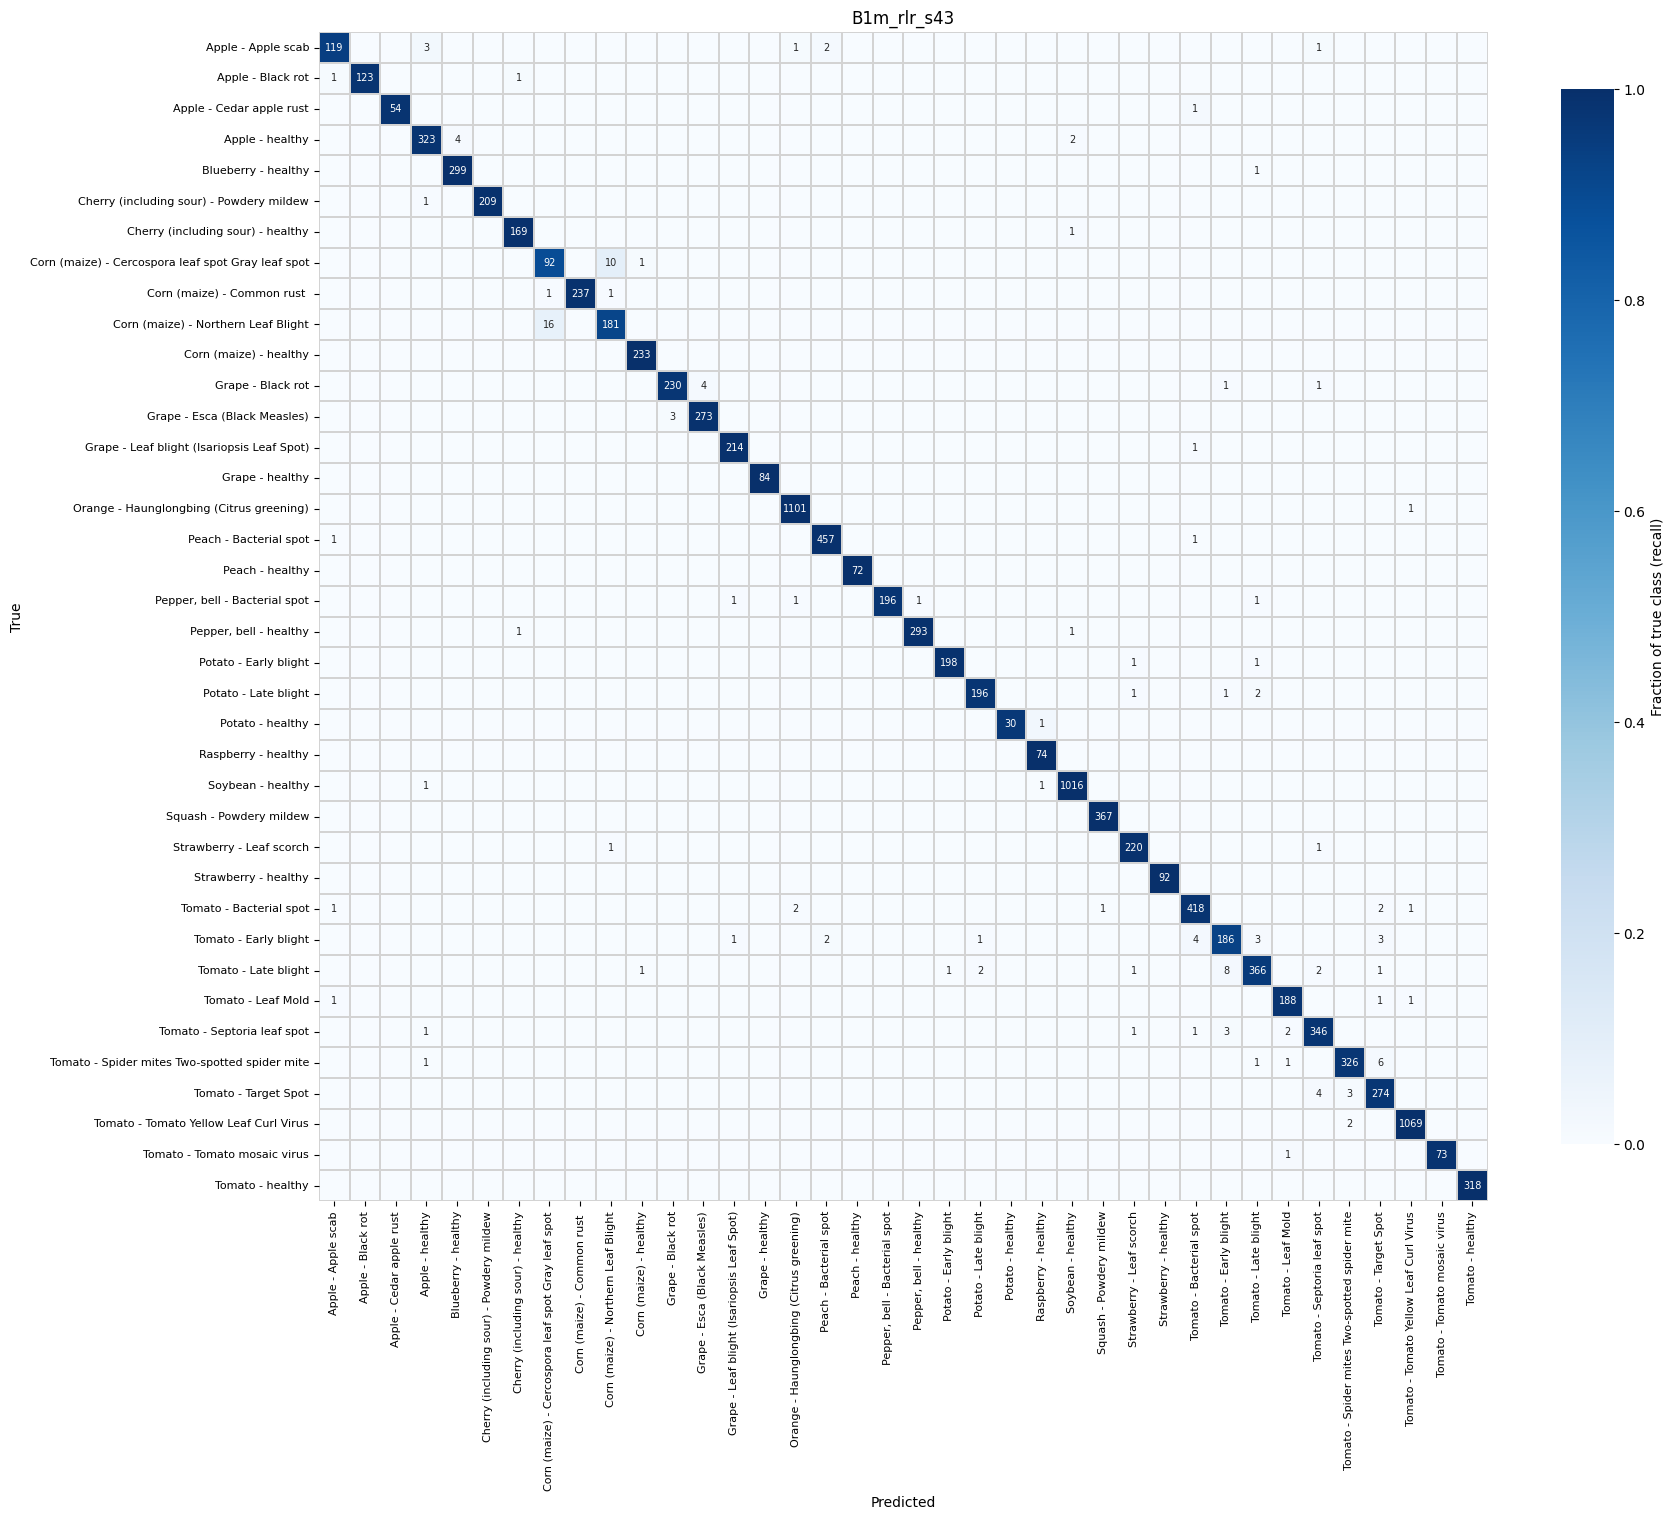


Top 10 confusions
count  % of true  total  true -> predicted
   16       8.1%    197  Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   10       9.7%    103  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Corn_(maize)___Northern_Leaf_Blight
    8       2.1%    382  Tomato___Late_blight -> Tomato___Early_blight
    6       1.8%    335  Tomato___Spider_mites Two-spotted_spider_mite -> Tomato___Target_Spot
    4       2.0%    200  Tomato___Early_blight -> Tomato___Bacterial_spot
    4       1.7%    236  Grape___Black_rot -> Grape___Esca_(Black_Measles)
    4       1.2%    329  Apple___healthy -> Blueberry___healthy
    4       1.4%    281  Tomato___Target_Spot -> Tomato___Septoria_leaf_spot
    3       1.1%    281  Tomato___Target_Spot -> Tomato___Spider_mites Two-spotted_spider_mite
    3       1.5%    200  Tomato___Early_blight -> Tomato___Late_blight

Watch list (lowest 5 recall)
precision  recall      f1  total  class -> most confused

(<Functional name=functional, built=True>,
 {'accuracy': 0.9866494536399841,
  'loss': 0.05037333071231842,
  'precision': 0.9868263602256775,
  'recall': 0.9862812161445618},
 array([[ 119,    0,    0, ...,    0,    0,    0],
        [   1,  123,    0, ...,    0,    0,    0],
        [   0,    0,   54, ...,    0,    0,    0],
        ...,
        [   0,    0,    0, ..., 1069,    0,    0],
        [   0,    0,    0, ...,    0,   73,    0],
        [   0,    0,    0, ...,    0,    0,  318]]))

In [50]:
evaluate_experiment("B1m_rlr_s43")

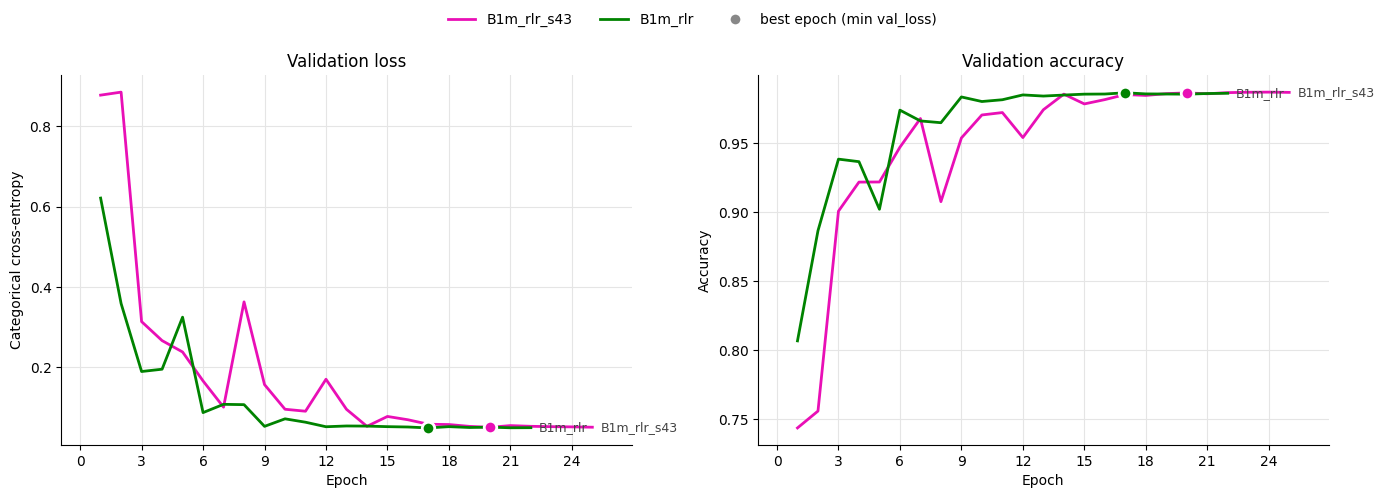

In [51]:
plot_val_curves(["B1m_rlr_s43", "B1m_rlr"])

In [52]:
# Probe rule from this run's own first LR cut (seeds differ, so B1m_rlr's epoch 6 doesn't carry over)
first_low_s43 = first_lr_cut_epoch("B1m_rlr_s43")
assert first_low_s43 is not None, "B1m_rlr_s43: LR was never cut, so the probe rule has no start epoch"
check_probe_rule("B1m_rlr_s43", from_epoch=first_low_s43)

[B1m_rlr_s43]  rule: probe_loss < 2.0 x loss from epoch 10
epoch      loss     probe   ratio
    1    0.7558    0.8472    1.12  
    2    0.2719    0.9026    3.32  
    3    0.1879    0.2896    1.54  
    4    0.1392    0.1803    1.30  
    5    0.1081    0.1800    1.67  
    6    0.0849    0.1035    1.22  
    7    0.0757    0.0545    0.72  
    8    0.0579    0.2511    4.34  
    9    0.0569    0.0593    1.04  
   10    0.0159    0.0083    0.52  ok
   11    0.0185    0.0129    0.70  ok
   12    0.0126    0.0782    6.19  FAIL
   13    0.0160    0.0151    0.94  ok
   14    0.0050    0.0008    0.16  ok
   15    0.0042    0.0049    1.18  ok
   16    0.0037    0.0015    0.42  ok
   17    0.0018    0.0004    0.22  ok
   18    0.0015    0.0007    0.45  ok
   19    0.0008    0.0001    0.18  ok
   20    0.0008    0.0002    0.28  ok
   21    0.0008    0.0002    0.18  ok
   22    0.0007    0.0002    0.35  ok
   23    0.0005    0.0001    0.20  ok
   24    0.0004    0.0001    0.22  ok
   25    0.

False

Best val_loss criterion PASS. Probe criterion FAIL at epoch 12 (LR 5e-4: probe 0.078, val 0.090 → 0.170); stable once LR ≤ 2.5e-4. Proceeding to B2 because the final model is reproducible across seeds; residual BN instability at LR 5e-4 is a known limitation.

Dropout is added under the Dense(128, activation='relu') layer because that layer has 70% of the model's parameters (262,272 of 361,094). Dropout is not added to the convolutional layers because they have only 30% of the parameters and are less likely to overfit. The dropout rate is set to 0.5, which is a common choice for fully connected layers.

In [59]:
# B2 model is adding Dropout to B1m_rlr
from tensorflow.keras.layers import Dropout

def build_b2_model(n_classes, bn_momentum=0.9, rate=0.5):
  inputs = Input(shape=(128, 128, 3))

  x = Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False)(inputs)
  x = BatchNormalization(momentum=bn_momentum)(x)
  x = Activation('relu')(x)
  x = MaxPooling2D(pool_size=(3, 3))(x)

  x = Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False)(x)
  x = BatchNormalization(momentum=bn_momentum)(x)
  x = Activation('relu')(x)
  x = MaxPooling2D(pool_size=(3, 3))(x)

  x = Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False)(x)
  x = BatchNormalization(momentum=bn_momentum)(x)
  x = Activation('relu')(x)
  x = MaxPooling2D(pool_size=(3, 3))(x)

  x = Flatten()(x)
  x = Dense(128, activation='relu')(x)
  x = Dropout(rate=rate)(x)
  outputs = Dense(n_classes, activation='softmax')(x)

  model = Model(inputs=inputs, outputs=outputs)
  return model

In [60]:
b2_test_model = build_b2_model(len(class_names))
b2_test_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 42, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 42, 42, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 42, 42, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 42, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,094 (1.38 MB)

 Trainable params: 360,646 (1.38 MB)

 Non-trainable params: 448 (1.75 KB)

In [61]:
print([l.momentum for l in b2_test_model.layers if isinstance(l, BatchNormalization)])

[0.9, 0.9, 0.9]


### Decision rule (best val_loss, B1m_rlr = 0.049, seed noise ≈ 0.002)
- | < 0.044: Dropout works → B2_d05 becomes the base for B3
- 0.044 – 0.054: no clear difference → try at most one more rate, or go to B3
- | > 0.054: worse → go to B3 from B1m_rlr, without Dropout

Fallback: no Dropout in the conv blocks (BN interaction), no more than 2 rates in total.

In [62]:
run_experiment("B2_d05", build_b2_model, extra_callbacks=[TrainProbe(probe_ds), make_rlr()])

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
Epoch 1/30
   1358/Unknown 142s 103ms/step - accuracy: 0.3229 - loss: 2.5496 - precision: 0.7858 - recall: 0.1848

/Users/myomyataung/workspace/projects/python/-practice-project--plant-disease-classifier/.venv/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 151s 111ms/step - accuracy: 0.3230 - loss: 2.5493 - precision: 0.7858 - recall: 0.1848 - val_accuracy: 0.6773 - val_loss: 1.1102 - val_precision: 0.8958 - val_recall: 0.4811 - epoch_time: 150.2054 - probe_loss: 1.0999 - probe_accuracy: 0.6826 - learning_rate: 0.0010
Epoch 2/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 193s 142ms/step - accuracy: 0.5223 - loss: 1.5331 - precision: 0.8309 - recall: 0.3899 - val_accuracy: 0.7089 - val_loss: 0.9524 - val_precision: 0.8977 - val_recall: 0.5581 - epoch_time: 191.9184 - probe_loss: 0.9553 - probe_accuracy: 0.7207 - learning_rate: 0.0010
Epoch 3/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 203s 149ms/step - accuracy: 0.5703 - loss: 1.3536 - precision: 0.8372 - recall: 0.4489 - val_accuracy: 0.7643 - val_loss: 0.7680 - val_precision: 0.8792 - val_recall: 0.6582 - epoch_time: 201.3784 - probe_loss: 0.7278 - probe_accuracy: 0.7754 - learning_rate: 0.0010
Epoch 4/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 212s 156ms/step - accuracy: 0.6183 - loss:

(<Functional name=functional, built=True>,
 <keras.src.callbacks.history.History at 0x32cd721f0>)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
[B2_d05] best epoch: 30 / 30
metric      evaluate   history
accuracy      0.9856    0.9856
loss          0.0557    0.0557
precision     0.9864    0.9864
recall        0.9851    0.9851

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.953     0.976     0.965       126
                                 Apple___Black_rot      1.000     0.992     0.996       125
                          Apple___Cedar_apple_rust      1.000     0.964     0.981        55
                                   Apple___healthy      0.970     0.988     0.979       329
                               Blueberry___healthy      0.993     0.990     0.992       300
          Cherry_(including_sour)___Powdery_mildew      1.000     0.995     0.998       210
                 Cherry_(including_sour)___healthy      0.994     0.988     0.991   

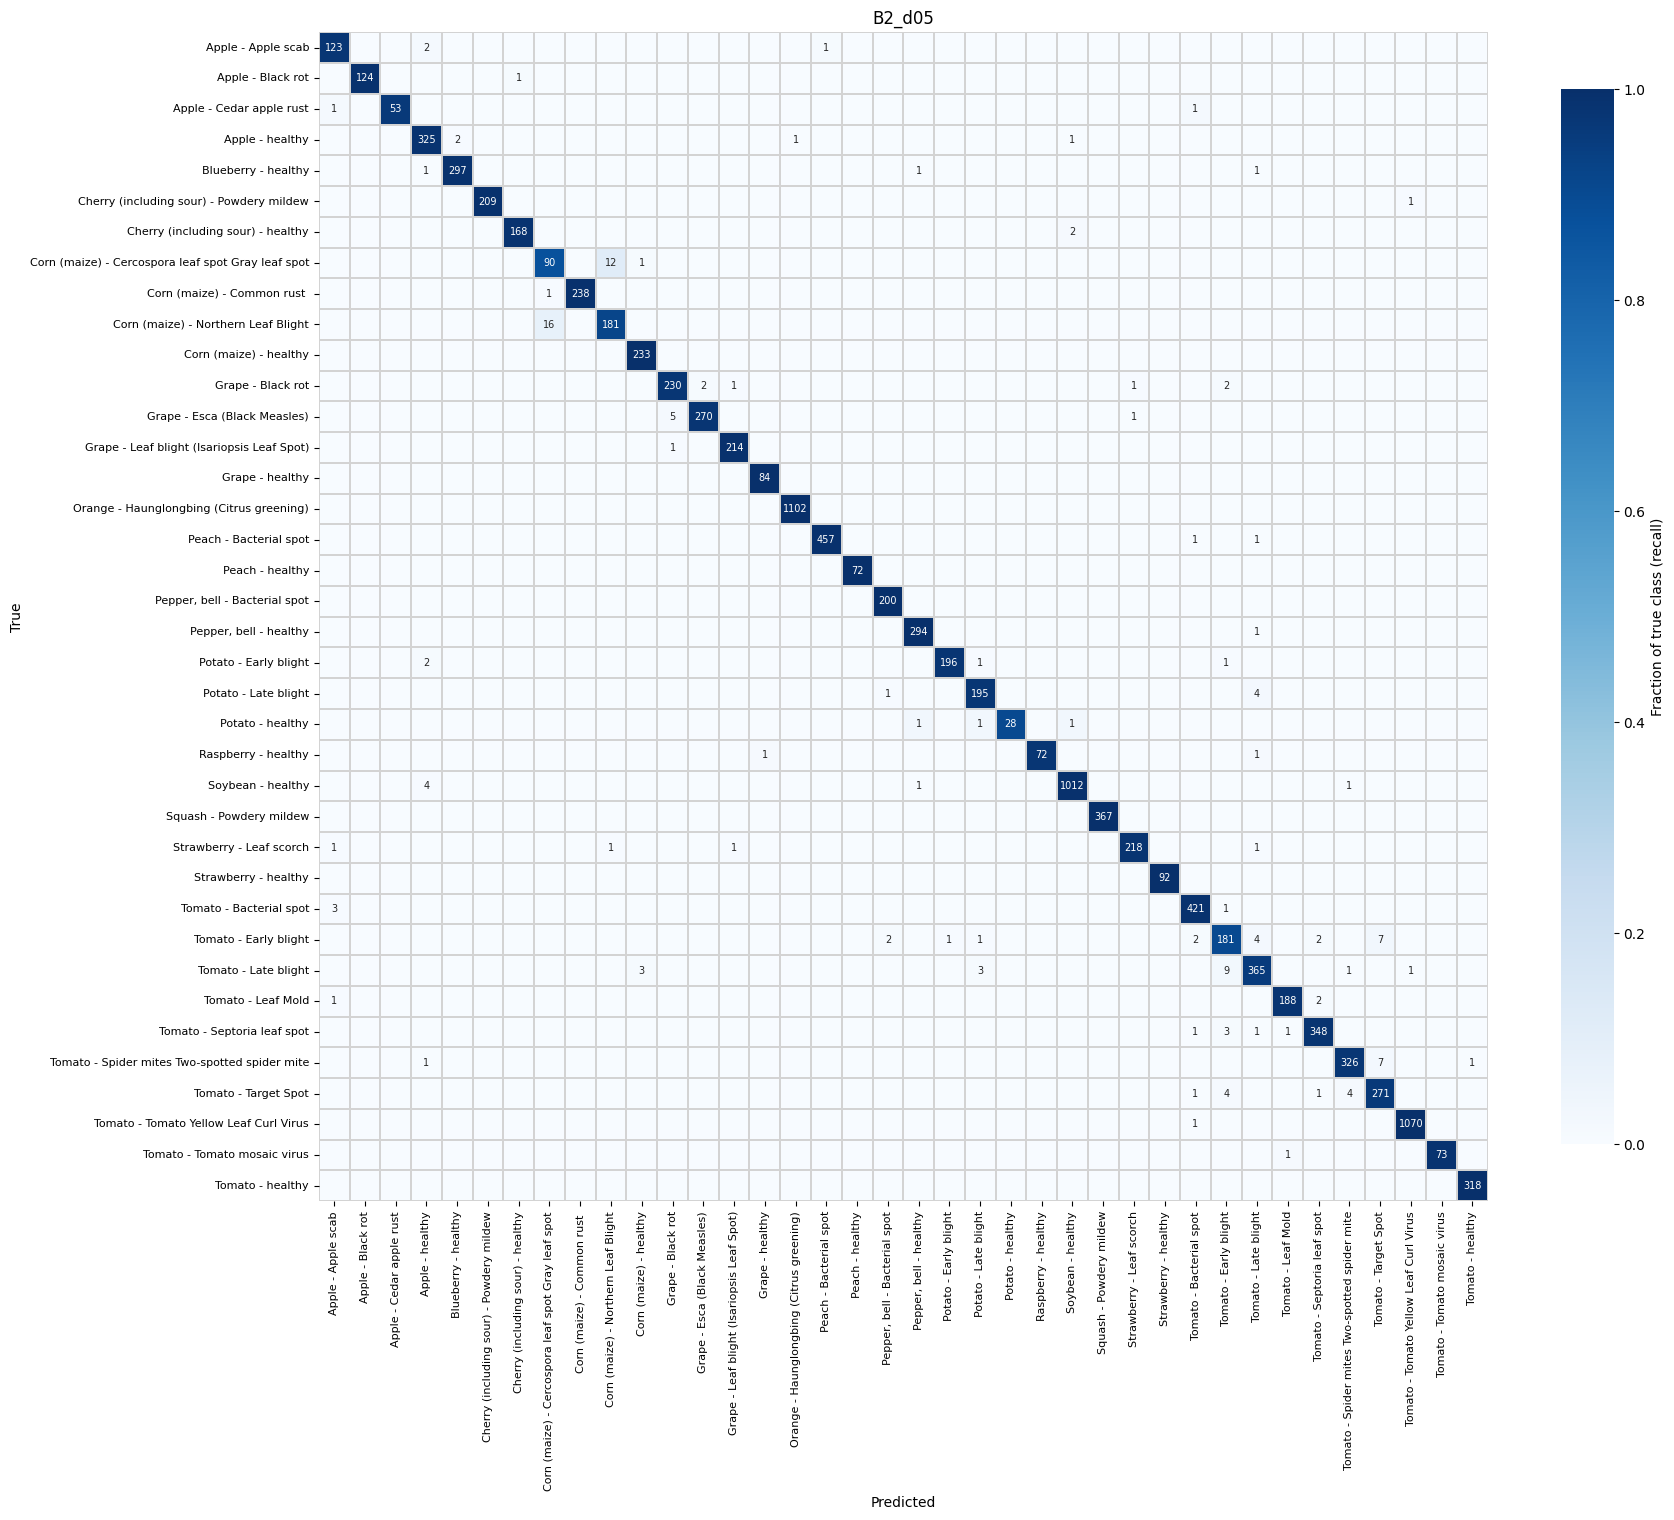


Top 10 confusions
count  % of true  total  true -> predicted
   16       8.1%    197  Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   12      11.7%    103  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Corn_(maize)___Northern_Leaf_Blight
    9       2.4%    382  Tomato___Late_blight -> Tomato___Early_blight
    7       3.5%    200  Tomato___Early_blight -> Tomato___Target_Spot
    7       2.1%    335  Tomato___Spider_mites Two-spotted_spider_mite -> Tomato___Target_Spot
    5       1.8%    276  Grape___Esca_(Black_Measles) -> Grape___Black_rot
    4       2.0%    200  Tomato___Early_blight -> Tomato___Late_blight
    4       1.4%    281  Tomato___Target_Spot -> Tomato___Early_blight
    4       1.4%    281  Tomato___Target_Spot -> Tomato___Spider_mites Two-spotted_spider_mite
    4       2.0%    200  Potato___Late_blight -> Tomato___Late_blight

Watch list (lowest 5 recall)
precision  recall      f1  total  class -> most confused wi

(<Functional name=functional, built=True>,
 {'accuracy': 0.9856367111206055,
  'loss': 0.05570273846387863,
  'precision': 0.9863556623458862,
  'recall': 0.9850842356681824},
 array([[ 123,    0,    0, ...,    0,    0,    0],
        [   0,  124,    0, ...,    0,    0,    0],
        [   1,    0,   53, ...,    0,    0,    0],
        ...,
        [   0,    0,    0, ..., 1070,    0,    0],
        [   0,    0,    0, ...,    0,   73,    0],
        [   0,    0,    0, ...,    0,    0,  318]]))

In [63]:
evaluate_experiment("B2_d05")

In [64]:
first_low_B2_d05 = first_lr_cut_epoch("B2_d05")
assert first_low_B2_d05 is not None, "B2_d05: LR was never cut, so the probe rule has no start epoch"
check_probe_rule("B2_d05", from_epoch=first_low_B2_d05)

[B2_d05]  rule: probe_loss < 2.0 x loss from epoch 17
epoch      loss     probe   ratio
    1    2.0992    1.0999    0.52  
    2    1.4870    0.9553    0.64  
    3    1.3023    0.7278    0.56  
    4    1.1517    0.5039    0.44  
    5    1.0306    0.4686    0.45  
    6    0.9185    0.3343    0.36  
    7    0.8092    0.2972    0.37  
    8    0.7115    0.2328    0.33  
    9    0.6326    0.2077    0.33  
   10    0.5368    0.1391    0.26  
   11    0.4302    0.1132    0.26  
   12    0.3502    0.2683    0.77  
   13    0.3201    0.1075    0.34  
   14    0.2898    0.0780    0.27  
   15    0.2596    0.0799    0.31  
   16    0.2412    0.0749    0.31  
   17    0.1845    0.0359    0.19  ok
   18    0.1609    0.0324    0.20  ok
   19    0.1548    0.0190    0.12  ok
   20    0.1433    0.0162    0.11  ok
   21    0.1345    0.0270    0.20  ok
   22    0.1048    0.0099    0.09  ok
   23    0.0969    0.0096    0.10  ok
   24    0.0932    0.0067    0.07  ok
   25    0.0918    0.0081    0.0

True

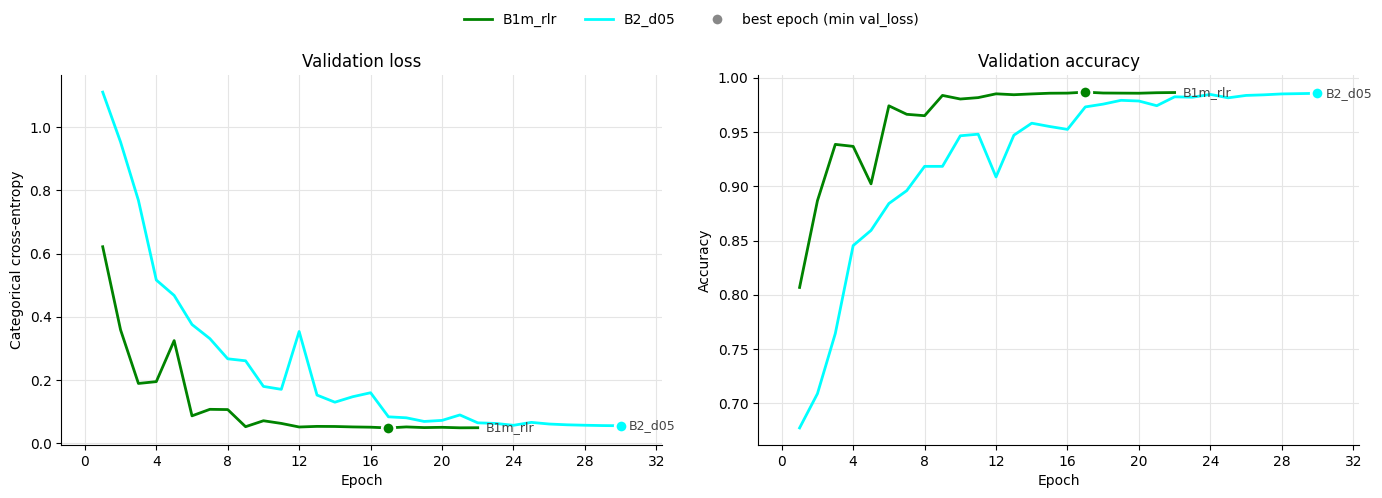

In [65]:
plot_val_curves(["B1m_rlr", "B2_d05"])

## 📌 Stopped here (2026-10-08)
- B2_d05 done: 0.0557 → "worse" per rule (hit 30-epoch cap). Not rerunning.
- Next base: B1m_rlr (no Dropout)
- TODO:
  1. Imbalance check: train count vs val recall per class (predict first!)
  2. Write B2 conclusion markdown
  3. B3 decisions: which augmentations? before/after cache? epochs → 50